<div class="nt-cover">
  <div class="nt-head">
    <span class="nt-label">NOTE TECHNIQUE</span>
    <span class="nt-num">02</span>
  </div>
  <div class="nt-title">Ce que le bonus-malus prend aux autres variables</div>
  <p class="nt-lede">Le bonus-malus est un coefficient réglementé qui multiplie une prime de
  référence. S'il sert en même temps de variable tarifaire, une partie du risque est comptée
  deux fois. Ce carnet construit un tarif de fréquence et de coût moyen sur un portefeuille
  automobile français, mesure ce double comptage à l'aide d'un graphe causal testé sur les
  données, puis livre une prime de référence sur laquelle le coefficient réglementaire
  s'applique sans le reproduire.</p>
  <div class="nt-meta">
    <div>
      <span class="nt-label nt-label-ink">DONNÉES</span>
      <p>freMTPL2, assureur automobile français, 2011 à 2013</p>
    </div>
    <div>
      <span class="nt-label nt-label-ink">PÉRIMÈTRE</span>
      <p>668 626 polices, 26 121 sinistres</p>
    </div>
    <div>
      <span class="nt-label nt-label-ink">MÉTHODE</span>
      <p>GLM de référence, EBM concurrent, graphe causal</p>
    </div>
  </div>
  <div class="nt-foot">
    <span>ARNAUD MBARGA &nbsp;·&nbsp; DIMITRI MEKONTSO</span>
    <span class="nt-src">Côté, Côté et Charpentier, 2025</span>
  </div>
</div>

In [1]:
import logging
from pathlib import Path
import matplotlib as mpl
from matplotlib import font_manager
from IPython.display import HTML, display

############################ Chargement de la charte
CSS = Path("charte_notebook.css").read_text(encoding = "utf-8")
display(HTML(f"<style>{CSS}</style>"))

############################ Configuration de la police
POLICE = "IBM Plex Sans"
polices_disponibles = {font.name for font in font_manager.fontManager.ttflist}
mpl.rcParams["font.family"] = POLICE if POLICE in polices_disponibles else "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = [POLICE, "DejaVu Sans", "Arial", "sans-serif"]
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

<h4>Sommaire</h4>

<div class="nt-toc">
  <a class="nt-toc-item" href="#part_1" style="text-decoration: none; color: inherit;"><span class="nt-n">01</span><span class="nt-t">La question posée</span><span class="nt-x">1 page</span></a>
  <a class="nt-toc-item" href="#part_2" style="text-decoration: none; color: inherit;"><span class="nt-n">02</span><span class="nt-t">Les données et ce qu'il faut en retirer</span><span class="nt-x">1 figure</span></a>
  <a class="nt-toc-item" href="#part_3" style="text-decoration: none; color: inherit;"><span class="nt-n">03</span><span class="nt-t">Le découpage des variables</span><span class="nt-x">1 figure</span></a>
  <a class="nt-toc-item" href="#part_4" style="text-decoration: none; color: inherit;"><span class="nt-n">04</span><span class="nt-t">Le GLM de fréquence</span><span class="nt-x">1 figure</span></a>
  <a class="nt-toc-item" href="#part_5" style="text-decoration: none; color: inherit;"><span class="nt-n">05</span><span class="nt-t">L'EBM face au GLM</span><span class="nt-x">1 tableau</span></a>
  <a class="nt-toc-item" href="#part_6" style="text-decoration: none; color: inherit;"><span class="nt-n">06</span><span class="nt-t">Le coût moyen</span><span class="nt-x">1 validation croisée</span></a>
  <a class="nt-toc-item" href="#part_7" style="text-decoration: none; color: inherit;"><span class="nt-n">07</span><span class="nt-t">Le graphe causal et sa validation</span><span class="nt-x">2 figures, 1 tableau</span></a>
  <a class="nt-toc-item" href="#part_8" style="text-decoration: none; color: inherit;"><span class="nt-n">08</span><span class="nt-t">Les primes et le double comptage</span><span class="nt-x">2 figures, 1 tableau, 3 contrôles</span></a>
  <a class="nt-toc-item" href="#part_9" style="text-decoration: none; color: inherit;"><span class="nt-n">09</span><span class="nt-t">Ce que la causalité apporte</span><span class="nt-x">1 page</span></a>
  <a class="nt-toc-item" href="#part_10" style="text-decoration: none; color: inherit;"><span class="nt-n">10</span><span class="nt-t">Limites</span><span class="nt-x">1 page</span></a>
</div>

In [2]:
%matplotlib inline

############################ Dépendances
# pip install pandas pyarrow statsmodels scikit-learn interpret-core matplotlib scipy
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from interpret.glassbox import ExplainableBoostingRegressor
from scipy.stats import chi2, f as loi_f
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

############################ Charte graphique
IVORY, INK, VIOLET = "#F7F5F1", "#0B0D12", "#3B2A55"
GREY, GREY2, RULE = "#3E3B36", "#5C584F", "#D6D1C7"
mpl.rcParams.update({
    "figure.facecolor": IVORY, "axes.facecolor": IVORY, "savefig.facecolor": IVORY,
    "font.size": 10, "figure.dpi": 110,
    "text.color": GREY, "axes.labelcolor": GREY2, "axes.edgecolor": RULE,
    "xtick.color": GREY2, "ytick.color": GREY2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.prop_cycle": mpl.cycler(color = [INK, VIOLET, GREY2])
})

############################ Paramètres communs
GRAINE = 2026
SEUIL_TEST = 0.001
def nombre(x, decimales = 0): return f"{x:,.{decimales}f}".replace(",", " ")

<div class="nt-section" id="part_1">
  <span class="nt-n">01</span>
  <span class="nt-t">La question posée</span>
</div>

<p class="nt-lede">En assurance automobile française, la prime due à chaque échéance est le
produit d'une prime de référence par le coefficient de réduction-majoration. Ce coefficient
est fixé par la réglementation, pas par l'assureur. La question de ce carnet est de savoir ce
que devient un tarif technique lorsque le bonus-malus y entre aussi comme variable
explicative.</p>

<div class="nt-list">
  <div class="nt-item">
    <span class="nt-n">01</span>
    <div>
      <p class="nt-h">Le bonus-malus n'est pas une variable comme les autres</p>
      <p class="nt-d">La clause type annexée à l'article A121-1 du Code des assurances pose un
      coefficient d'origine de 1, réduit de 5 pour cent par année sans sinistre, majoré de
      25 pour cent par sinistre, avec un plancher de 0,50. Ce coefficient multiplie la prime de
      référence, c'est-à-dire le tarif technique de l'assureur. Utiliser en plus le bonus-malus
      comme variable du tarif technique revient donc à le faire intervenir deux fois.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">02</span>
    <div>
      <p class="nt-h">Il absorbe une partie de l'effet des autres variables</p>
      <p class="nt-d">Le coefficient dépend de l'ancienneté de conduite et de l'historique de
      sinistres. Un conducteur de vingt ans ne peut pas avoir accumulé de bonus. Un tarif qui
      ignore le bonus-malus attribue à l'âge un effet que le tarif qui le contient attribue au
      coefficient. La question n'est pas de savoir lequel des deux a raison, mais de séparer les
      deux parts.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">03</span>
    <div>
      <p class="nt-h">La séparation demande une hypothèse sur les mécanismes</p>
      <p class="nt-d">Une corrélation ne dit pas si l'âge explique le coefficient, l'inverse, ou
      si les deux dépendent d'une même cause non observée. Nous écrivons donc un graphe causal
      explicite, nous testons ses implications sur les données, puis nous calculons quatre des
      cinq familles de primes de Côté, Côté et Charpentier : best estimate, unaware, aware et
      corrective.</p>
    </div>
  </div>
</div>

<h4>CE QUE LE CARNET PRODUIT</h4>

<p>Un tarif de prime pure complet, une mesure de ce qu'un modèle d'apprentissage y ajoute ou
n'y ajoute pas, une mesure du double comptage entre ce tarif et le coefficient réglementaire,
et une prime de référence estimée sous ce coefficient, sur laquelle il s'applique sans double
comptage.</p>

<div class="nt-note">
Référence principale : O. Côté, M.-P. Côté, A. Charpentier, <em>A fair price to pay:
Exploiting causal graphs for fairness in insurance</em>, Journal of Risk and Insurance, 92,
33 à 75, 2025. La prime aware correspond au prix sans discrimination de M. Lindholm,
R. Richman, A. Tsanakas, M. Wüthrich, ASTIN Bulletin, 52, 2022.
</div>

<div class="nt-limit">
  <span class="nt-label">UN SEUIL UNIQUE POUR TOUS LES TESTS</span>
  <p>Le portefeuille compte plus de six cent mille polices. À cette taille, un test rejette
  presque toujours l'hypothèse nulle, y compris pour des écarts sans portée tarifaire. Tous les
  tests de modélisation utilisent donc un seuil de 1 pour mille, et chaque décision est prise en
  regardant aussi l'ampleur de l'effet, pas seulement sa p-valeur. Les tests du graphe causal,
  en partie 07, sont jugés sur l'ampleur seule.</p>
</div>

<div class="nt-section" id="part_2">
  <span class="nt-n">02</span>
  <span class="nt-t">Les données et ce qu'il faut en retirer</span>
</div>

<p class="nt-lede">freMTPL2 rassemble les caractéristiques de risque et les sinistres de polices
de responsabilité civile automobile françaises observées autour de 2011 à 2013. Les deux
fichiers fournis portent des noms croisés : le fichier nommé sinistres contient les polices,
le fichier nommé contrats contient les montants. Une colonne d'index parasite traîne dans le
second.</p>

In [3]:
############################ Chargement : les noms des deux fichiers sont croisés
polices = pd.read_parquet("sinistres.parquet")
montants = pd.read_csv("contrats.csv").drop(columns = ["Unnamed: 0"])
polices["IDpol"] = polices["IDpol"].astype("int64")
print(f"sinistres.parquet : {nombre(len(polices))} lignes, colonnes {list(polices.columns)}")
print(f"contrats.csv      : {nombre(len(montants))} lignes, colonnes {list(montants.columns)}")

sinistres.parquet : 678 013 lignes, colonnes ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']
contrats.csv      : 26 639 lignes, colonnes ['IDpol', 'ClaimAmount']


<p class="nt-caption">Les polices dont l'identifiant est inférieur à
24 952 sont toutes sinistrées et n'ont presque jamais de montant associé.</p>

<p>Ce défaut est documenté. Wüthrich et Merz le signalent dans l'annexe B de leur ouvrage,
d'après Loser, avec un seuil situé à 24 500. Sur ces données, le profil est net : 9 387
polices sont concernées, 100 pour cent d'entre elles sont sinistrées et 3,1
pour cent seulement portent un montant. La première police non sinistrée porte l'identifiant
24 952. Ces lignes sont retirées.</p>

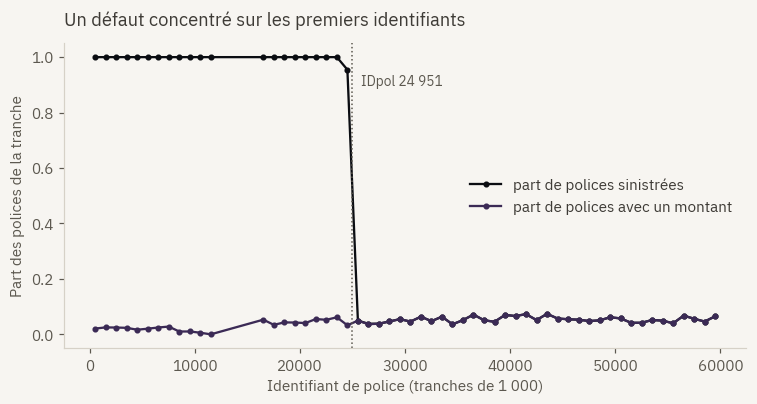

IDpol <= 24951 : 9 387 polices, 100.0 % sinistrées, 3.1 % avec un montant
Premier identifiant non sinistré : 24952


In [4]:
############################ Nombre de montants rattachés à chaque police
nb_montants = montants.groupby("IDpol").size()
polices["NbMontants"] = polices["IDpol"].map(nb_montants).fillna(0).astype(int)

############################ Profil le long des identifiants
SEUIL_ID = 24_951
tranches = pd.cut(polices["IDpol"], np.arange(0, 60_001, 1_000))
profil = polices.groupby(tranches, observed = True).agg(
    sinistrees = ("ClaimNb", lambda s: (s > 0).mean()),
    avec_montant = ("NbMontants", lambda s: (s > 0).mean()))
milieux = [intervalle.mid for intervalle in profil.index]

fig, ax = plt.subplots(figsize = (8, 3.6))
ax.plot(milieux, profil["sinistrees"], color = INK, marker = "o", markersize = 3, label = "part de polices sinistrées")
ax.plot(milieux, profil["avec_montant"], color = VIOLET, marker = "o", markersize = 3, label = "part de polices avec un montant")
ax.axvline(SEUIL_ID, color = GREY2, linestyle = ":", linewidth = 1)
ax.text(SEUIL_ID + 800, 0.9, "IDpol 24 951", color = GREY2, fontsize = 9)
ax.set_xlabel("Identifiant de police (tranches de 1 000)")
ax.set_ylabel("Part des polices de la tranche")
ax.set_title("Un défaut concentré sur les premiers identifiants")
ax.legend(frameon = False, loc = "center right")
plt.show()

avant = polices[polices["IDpol"] <= SEUIL_ID]
print(f"IDpol <= {SEUIL_ID} : {nombre(len(avant))} polices, {100 * (avant['ClaimNb'] > 0).mean():.1f} % sinistrées, "
      f"{100 * (avant['NbMontants'] > 0).mean():.1f} % avec un montant")
print("Premier identifiant non sinistré :", polices.loc[polices["ClaimNb"] == 0, "IDpol"].min())

<p class="nt-caption">Contrôles après nettoyage. Le nombre de sinistres
est plafonné à quatre par police et l'exposition à un an.</p>

<p>Le plafonnement du nombre de sinistres écarte quelques comptages douteux, celui de l'exposition
ramène à un an les contrats observés plus longtemps. Après nettoyage, le nombre de
sinistres déclarés et le nombre de montants rattachés concordent sur 99,995 pour cent des
polices ; 22 polices sinistrées n'ont aucun montant.</p>

In [5]:
############################ Retraitements
base = polices[polices["IDpol"] > SEUIL_ID].copy()
base["ClaimNb"] = base["ClaimNb"].clip(upper = 4)
base["Exposure"] = base["Exposure"].clip(upper = 1)
base = base.reset_index(drop = True)

############################ Contrôles
controles = pd.Series({
    "Polices": len(base),
    "Sinistres": base["ClaimNb"].sum(),
    "Fréquence annuelle (%)": round(100 * base["ClaimNb"].sum() / base["Exposure"].sum(), 2),
    "Montants rattachés": base["NbMontants"].sum(),
    "Polices où nombre et montants concordent (%)": round(100 * (base["ClaimNb"] == base["NbMontants"]).mean(), 3),
    "Polices sinistrées sans montant": ((base["ClaimNb"] > 0) & (base["NbMontants"] == 0)).sum(),
    "Montants sans police": (~montants["IDpol"].isin(polices["IDpol"])).sum()
})
controles.to_frame("Valeur")

,Valeur
Polices,668626.000
Sinistres,26121.000
Fréquence annuelle (%),7.390
Montants rattachés,26137.000
Polices où nombre et montants concordent (%),99.995
Polices sinistrées sans montant,22.000
Montants sans police,195.000


<p class="nt-caption">Area est un découpage exact de Density : les
intervalles de densité de deux modalités ne se chevauchent pas.</p>

<p>Area ne contient donc aucune information que Density ne contienne déjà, en plus fin. La
variable est écartée du graphe causal et du tarif ; sa contribution résiduelle sera tout de
même testée dans le GLM.</p>

In [6]:
############################ Area découpe Density
base.groupby("Area").agg(densite_min = ("Density", "min"), densite_max = ("Density", "max"),
                         polices = ("IDpol", "size")).T

Area,A,B,C,D,E,F
densite_min,1,50,100,500,2001,10008
densite_max,50,100,500,1993,9850,27000
polices,102309,74322,189175,149700,135522,17598


<p class="nt-caption">Quelques montants reviennent des milliers de
fois.</p>

<div class="nt-limit">
  <span class="nt-label">DES MONTANTS FORFAITAIRES</span>
  <p>Le montant de 1 204 EUR représente 18,3 pour cent des sinistres rattachés, et trois
  autres valeurs, 1 128,12, 1 172 et 1 128 EUR, en représentent 22,5 pour cent de plus.
  La documentation de CASdatasets précise qu'une partie des montants de freMTPL2sev sont des
  montants forfaitaires issus de la convention IRSA-IDA de règlement entre assureurs, sans
  indiquer lesquels. Ces valeurs répétées en sont vraisemblablement l'expression : le montant y
  est fixé par la convention, pas par le coût réel du sinistre. Cette concentration pèse sur
  toute modélisation fine du coût moyen.</p>
</div>


In [7]:
############################ Montants les plus fréquents
montants_base = montants.merge(base[["IDpol"]], on = "IDpol")
frequents = montants_base["ClaimAmount"].value_counts().head(4)
pd.DataFrame({"Sinistres": frequents, "Part (%)": (100 * frequents / len(montants_base)).round(1)})

,Sinistres,Part (%)
ClaimAmount,,
1204.00,4792,18.3
1128.12,2975,11.4
1172.00,2071,7.9
1128.00,831,3.2


In [8]:
############################ Partition apprentissage 90 %, test 10 %
permutation = np.random.default_rng(GRAINE).permutation(len(base))
base["Test"] = False
base.loc[permutation[: len(base) // 10], "Test"] = True
app = base[~base["Test"]].reset_index(drop = True)
test = base[base["Test"]].reset_index(drop = True)
y_app, off_app = app["ClaimNb"].values, np.log(app["Exposure"].values)
y_test, off_test = test["ClaimNb"].values, np.log(test["Exposure"].values)
print(f"Apprentissage : {nombre(len(app))} polices, fréquence {app['ClaimNb'].sum() / app['Exposure'].sum():.4f}")
print(f"Test          : {nombre(len(test))} polices, fréquence {test['ClaimNb'].sum() / test['Exposure'].sum():.4f}")

Apprentissage : 601 764 polices, fréquence 0.0741
Test          : 66 862 polices, fréquence 0.0720


<div class="nt-section" id="part_3">
  <span class="nt-n">03</span>
  <span class="nt-t">Le découpage des variables</span>
</div>

<p class="nt-lede">Un GLM tarifaire travaille sur des classes. Le découpage est la décision la
plus structurante du modèle, et la moins testée en pratique. Trois sources sont croisées ici :
la fréquence observée pondérée par l'exposition, la forme estimée par un modèle additif
généralisé par boosting, et des arbres de Poisson ajustés sur les résidus d'un GLM. Chaque
coupure est ensuite testée, éprouvée par bootstrap, puis arbitrée par le métier.</p>

In [9]:
############################ Outils : matrice de tarif, ajustement de Poisson, déviance
def classes(x, bornes):
    # bornes supérieures incluses : [20, 23] donne <= 20, 21-23, > 23
    return np.searchsorted(np.asarray(bornes), x, side = "left")

def modalites(d, v, forme):
    nature, arg = forme
    if nature == "coupe":
        return classes(d[v].values, arg)
    if nature == "groupe":
        return d[v].map(arg).values
    return d[v].values

def matrice(d, spec, refs = None, continues = None):
    colonnes, noms, refs_sortie = [np.ones(len(d))], ["constante"], {}
    for v, forme in spec.items():
        k = modalites(d, v, forme)
        if refs is None:
            niveaux = np.unique(k)
            ref = pd.Series(d["Exposure"].values).groupby(k).sum().idxmax()
        else:
            ref, niveaux = refs[v]
        refs_sortie[v] = (ref, niveaux)
        for niveau in niveaux:
            if niveau != ref:
                colonnes.append((k == niveau).astype(float))
                noms.append(f"{v}[{niveau}]")
    if continues is not None:
        valeurs, noms_continus = continues(d)
        colonnes += list(valeurs.T)
        noms += noms_continus
    return np.column_stack(colonnes), noms, refs_sortie

def poisson(y, X, offset, depart = None):
    if depart is None:
        depart = np.zeros(X.shape[1])
        depart[0] = np.log(y.sum() / np.exp(offset).sum())
    return sm.GLM(y, X, family = sm.families.Poisson(), offset = offset).fit(
        method = "newton", start_params = depart, max_start_irls = 0, maxiter = 50, disp = 0)

def deviance(y, mu):
    terme = np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0)
    return 200 * np.mean(terme - (y - mu))

def rapport_vraisemblance(complet, reduit):
    stat = 2 * (complet.llf - reduit.llf)
    ddl = len(complet.params) - len(reduit.params)
    return round(stat, 1), ddl, chi2.sf(stat, ddl)

<h4>UN MODÈLE D'APPRENTISSAGE AJUSTÉ UNE FOIS, UTILISÉ DEUX FOIS</h4>

<p>L'EBM est un modèle additif par boosting d'arbres peu profonds, dont chaque effet reste
lisible. Il reçoit les variables brutes, sans aucun découpage manuel : il découpe lui-même
chaque variable continue en intervalles de même effectif, jusqu'à 1 024. Le bonus-malus est
contraint croissant. La cible est le nombre de sinistres, avec le logarithme de l'exposition en
score initial, et l'objectif est la déviance de Poisson.</p>

<p>Il sert ici de lecteur de formes pour proposer les coupures du GLM. Il est jugé comme
modélisation concurrente en partie 05, sur l'échantillon test.</p>

In [10]:
############################ EBM de fréquence : variables brutes, bonus-malus croissant
VARIABLES = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "VehBrand", "VehGas", "Density", "Region"]
TYPES = ["continuous"] * 4 + ["nominal", "nominal", "continuous", "nominal"]
t0 = time.time()
ebm = ExplainableBoostingRegressor(
    feature_names = VARIABLES, feature_types = TYPES, objective = "poisson_deviance",
    monotone_constraints = [1 if v == "BonusMalus" else 0 for v in VARIABLES],
    interactions = 10, n_jobs = 1, random_state = GRAINE)
ebm.fit(app[VARIABLES], y_app, init_score = off_app)
print(f"EBM ajusté en {time.time() - t0:.0f} s ; interactions retenues : {ebm.term_names_[len(VARIABLES):]}")

EBM ajusté en 166 s ; interactions retenues : ['VehPower & DrivAge', 'VehPower & VehBrand', 'VehAge & DrivAge', 'VehAge & VehBrand', 'VehAge & Density', 'VehAge & Region', 'DrivAge & VehBrand', 'DrivAge & Density', 'DrivAge & Region', 'Density & Region']


<h4>LES ARBRES SUR RÉSIDUS</h4>

<p>Pour chaque variable, un GLM est ajusté sans elle, et ses prédictions servent d'offset. Un
arbre de régression de Poisson est alors ajusté sur cette variable seule : il découpe là où la
sinistralité s'écarte de ce que les autres variables expliquent déjà. En faisant croître le
nombre de feuilles une par une, on obtient une suite de découpages emboîtés, que l'on compare
par test du rapport de vraisemblance. La suite s'arrête à la première coupure dont l'apport
n'est plus significatif à 1 pour mille. Chaque coupure retenue est ensuite recherchée dans
trente arbres ajustés sur des échantillons bootstrap : sa stabilité est la part des tirages où
elle réapparaît, à une unité près.</p>

In [11]:
############################ GLM préliminaire, classes de départ usuelles
PRELIM = {"DrivAge": ("coupe", [20, 25, 30, 40, 50, 60, 70]), "VehAge": ("coupe", [0, 5, 10, 15]),
          "VehPower": ("coupe", [5, 6, 7, 8, 9]), "BonusMalus": ("coupe", [50, 55, 60, 70, 80, 90, 99, 100, 110, 130]),
          "Density": ("coupe", [50, 100, 500, 2000, 10000]),
          "VehBrand": ("brut", None), "VehGas": ("brut", None), "Region": ("brut", None)}

def attendu_sans(v):
    spec = {k: forme for k, forme in PRELIM.items() if k != v}
    X, _, _ = matrice(app, spec)
    return np.exp(X @ poisson(y_app, X, off_app).params + off_app)

def arbre(x, mu, feuilles, lignes = None):
    lignes = slice(None) if lignes is None else lignes
    modele = DecisionTreeRegressor(criterion = "poisson", max_leaf_nodes = feuilles,
                                   min_weight_fraction_leaf = 0.005, random_state = 0)
    modele.fit(x[lignes].reshape(-1, 1), y_app[lignes] / mu[lignes], sample_weight = mu[lignes])
    return np.sort(modele.tree_.threshold[modele.tree_.feature >= 0])

def suite_emboitee(x, mu, max_feuilles = 12):
    lignes, precedent = [], None
    for feuilles in range(1, max_feuilles + 1):
        coupures = arbre(x, mu, feuilles) if feuilles > 1 else np.array([])
        k = np.searchsorted(coupures, x, side = "right")
        X = np.column_stack([(k == j).astype(float) for j in range(len(coupures) + 1)])
        ajustement = sm.GLM(y_app, X, family = sm.families.Poisson(), offset = np.log(mu)).fit(
            method = "newton", start_params = np.zeros(X.shape[1]), max_start_irls = 0, disp = 0)
        stat = np.nan if precedent is None else 2 * (ajustement.llf - precedent)
        precedent = ajustement.llf
        lignes.append({"classes": feuilles, "coupures": coupures, "LR": stat, "p": chi2.sf(stat, 1)})
    suite = pd.DataFrame(lignes)
    rejets = suite.loc[suite["p"] >= SEUIL_TEST, "classes"]
    retenu = rejets.min() - 1 if len(rejets) else max_feuilles
    return suite, retenu

############################ Coupures proposées et stabilité bootstrap (30 tirages)
TOLERANCE = {"DrivAge": 1, "VehAge": 1, "VehPower": 0.5, "BonusMalus": 2, "Density": 0.15}
N_TIRAGES = 30
tirage = np.random.default_rng(GRAINE)
propositions, attendus, STABLES, COUPURES_ARBRES = [], {}, {}, {}
for v in TOLERANCE:
    mu = attendu_sans(v)
    attendus[v] = mu
    x = np.log(app[v].values) if v == "Density" else app[v].values.astype(float)
    suite, retenu = suite_emboitee(x, mu)
    coupures = suite.loc[suite["classes"] == retenu, "coupures"].iloc[0] if retenu >= 2 else np.array([])
    presences = np.zeros(len(coupures))
    for _ in range(N_TIRAGES if len(coupures) else 0):
        lignes = tirage.integers(0, len(y_app), len(y_app))
        autres = arbre(x, mu, retenu, lignes)
        presences += [np.any(np.abs(autres - c) <= TOLERANCE[v]) for c in coupures]
    stabilite = presences / max(N_TIRAGES, 1)
    COUPURES_ARBRES[v] = coupures
    # une coupure est retenue si elle réapparaît dans au moins 70 % des tirages
    STABLES[v] = [int(np.floor(c)) for c, s in zip(coupures, stabilite) if s >= 0.70]
    affichage = np.exp(coupures).round() if v == "Density" else coupures
    propositions.append({"Variable": v, "Classes": retenu,
                         "Coupures proposées": ", ".join(f"{c:g}" for c in affichage),
                         "Stabilité (%)": ", ".join(f"{100 * s:.0f}" for s in stabilite)})
pd.DataFrame(propositions).set_index("Variable")

,Classes,Coupures proposées,Stabilité (%)
Variable,,,
DrivAge,8,"20.5, 21.5, 23.5, 34.5, 39.5, 43.5, 53.5","100, 90, 87, 57, 93, 93, 63"
VehAge,3,"12.5, 17.5","93, 97"
VehPower,3,"4.5, 8.5","73, 87"
BonusMalus,12,"51.5, 57.5, 58.5, 61.5, 63.5, 64.5, 67.5, 68.5...","83, 97, 97, 100, 100, 100, 87, 87, 43, 100, 100"
Density,3,"19, 393","33, 90"


In [12]:
############################ Coupures stables conservées, bornes supérieures incluses
pd.Series({v: ", ".join(map(str, c)) or "aucune" for v, c in STABLES.items()}).to_frame("Coupures stables")

,Coupures stables
DrivAge,"20, 21, 23, 39, 43"
VehAge,"12, 17"
VehPower,"4, 8"
BonusMalus,"51, 57, 58, 61, 63, 64, 67, 68, 95, 100"
Density,5


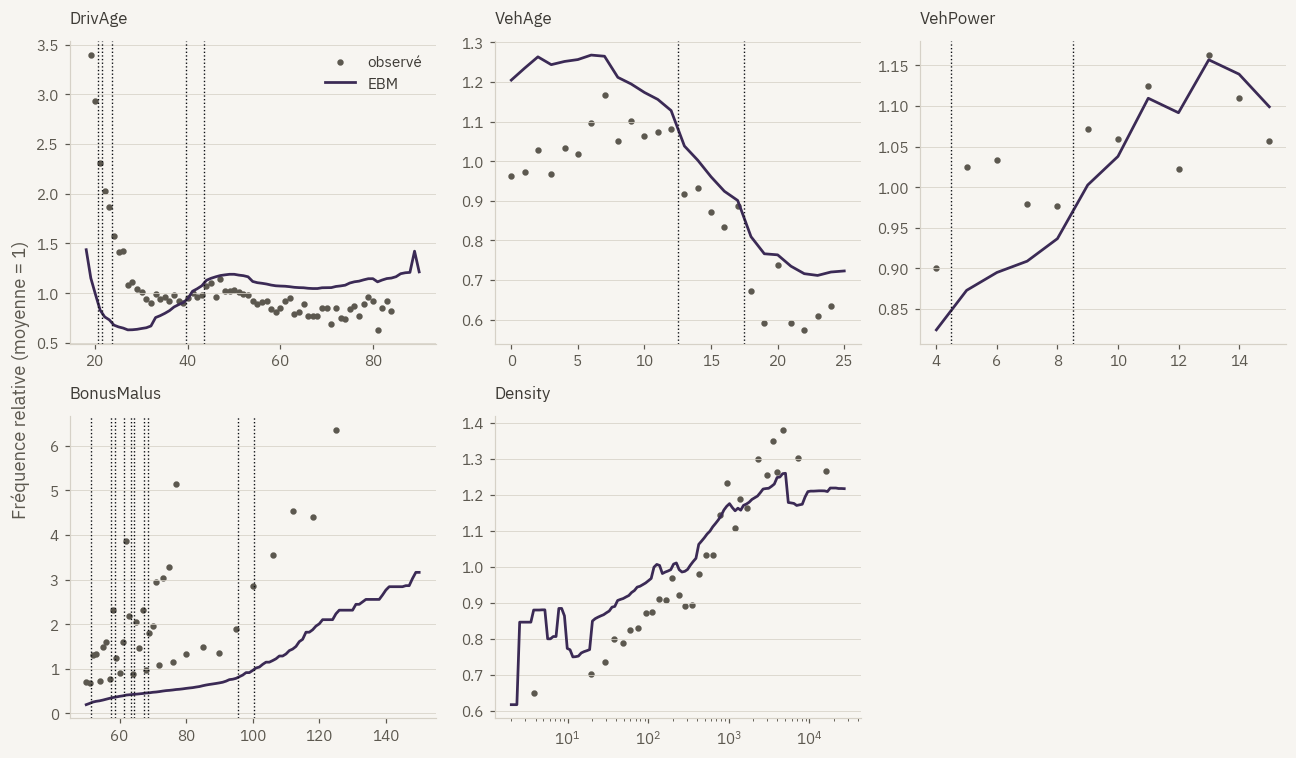

In [13]:
############################ Formes : fréquence observée, EBM, coupures stables
def forme_ebm(v, grille):
    reference = app[VARIABLES].mode().iloc[[0]]
    cadre = pd.concat([reference] * len(grille), ignore_index = True)
    cadre[v] = grille
    contributions = ebm.eval_terms(cadre)[:, VARIABLES.index(v)]
    return contributions

fig, axes = plt.subplots(2, 3, figsize = (12, 7))
frequence_moyenne = app["ClaimNb"].sum() / app["Exposure"].sum()
for ax, v in zip(axes.flat, ["DrivAge", "VehAge", "VehPower", "BonusMalus", "Density"]):
    if v == "Density":
        cle = pd.qcut(np.log(app["Density"]), 30, duplicates = "drop")
        obs = app.groupby(cle, observed = True).agg(e = ("Exposure", "sum"), n = ("ClaimNb", "sum"))
        abscisse_obs = np.exp([i.mid for i in obs.index])
        grille = np.exp(np.linspace(np.log(2), np.log(27000), 120))
    else:
        haut = {"DrivAge": 90, "VehAge": 25, "VehPower": 15, "BonusMalus": 150}[v]
        obs = app[app[v] <= haut].groupby(v).agg(e = ("Exposure", "sum"), n = ("ClaimNb", "sum"))
        obs = obs[obs["e"] >= 300]
        abscisse_obs = obs.index.values
        grille = np.arange(app[v].min(), haut + 1)
    contributions = forme_ebm(v, grille)
    ax.scatter(abscisse_obs, obs["n"] / obs["e"] / frequence_moyenne, s = 10, color = GREY2, label = "observé")
    ax.plot(grille, np.exp(contributions - np.average(contributions)), color = VIOLET, linewidth = 1.8, label = "EBM")
    if v != "Density":
        for c in STABLES[v]:
            ax.axvline(c + 0.5, color = INK, linestyle = ":", linewidth = 0.9)
    else:
        ax.set_xscale("log")
    ax.set_title(v, fontsize = 11)
    ax.grid(axis = "y", color = RULE, linewidth = 0.5)
axes.flat[0].legend(frameon = False)
axes.flat[5].axis("off")
fig.supylabel("Fréquence relative (moyenne = 1)", color = GREY2)
fig.tight_layout()
plt.show()

<p class="nt-caption">Points gris : fréquence observée rapportée à la
fréquence moyenne du portefeuille, classes d'exposition suffisante seulement. Trait violet :
forme estimée par l'EBM, les autres variables étant fixées. Pointillés : coupures stables
proposées par les arbres.</p>

<p>Les trois lectures se recoupent sur l'âge du conducteur, l'âge du véhicule et la puissance.
Elles divergent sur deux points.</p>

<div class="nt-list">
  <div class="nt-item">
    <span class="nt-n">01</span>
    <div>
      <p class="nt-h">Le bonus-malus n'est pas croissant en observé</p>
      <p class="nt-d">Les points observés se dispersent largement autour de la courbe
      croissante de l'EBM. La raison est mécanique : la valeur du coefficient porte une
      information de calendrier. Les valeurs de la trajectoire sans sinistre, obtenues en
      multipliant par 0,95 chaque année, alternent avec les valeurs issues d'une majoration
      récente de 25 pour cent. Entre 50 et 70, deux coefficients voisins vont ainsi d'environ
      0,7 à près de 4 fois la fréquence moyenne du portefeuille. Exiger un tarif croissant en
      fonction du coefficient, ce qui est la logique même du mécanisme réglementaire, revient à
      renoncer à cette information. Nous conservons l'exigence et nous en mesurons le prix en
      partie 05.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">02</span>
    <div>
      <p class="nt-h">La densité monte sans palier net</p>
      <p class="nt-d">La fréquence monte régulièrement avec le logarithme de la densité,
      sans palier net. Les arbres ne trouvent qu'une coupure stable, à 393 habitants par km²,
      présente dans 90 pour cent des tirages contre 33 pour cent pour la seconde. Une forme
      log-linéaire décrit cette montée avec un seul paramètre et obtient une log-vraisemblance
      supérieure à celle du découpage en classes qui en consomme deux, moins 95 102,3 contre
      moins 95 104,4.</p>
    </div>
  </div>
</div>

In [14]:
############################ Regroupement des modalités de Region et VehBrand
def regrouper(v, max_feuilles = 10):
    mu = attendu_sans(v)
    def ordre_et_groupes(lignes, feuilles = None):
        cadre = pd.DataFrame({"m": app[v].values[lignes], "y": y_app[lignes], "mu": mu[lignes]})
        somme = cadre.groupby("m")[["y", "mu"]].sum()
        ordre = (somme["y"] / somme["mu"]).sort_values()
        rang = app[v].map({m: i for i, m in enumerate(ordre.index)}).values.astype(float)
        return ordre, rang
    ordre, rang = ordre_et_groupes(np.arange(len(y_app)))
    suite, retenu = suite_emboitee(rang, mu, max_feuilles)
    coupures = suite.loc[suite["classes"] == retenu, "coupures"].iloc[0]
    groupes = dict(zip(ordre.index, np.searchsorted(coupures, np.arange(len(ordre)), side = "right")))
    # stabilité : part des paires de modalités traitées de la même façon (indice de Rand)
    niveaux = list(ordre.index)
    indices = []
    for _ in range(30):
        lignes = tirage.integers(0, len(y_app), len(y_app))
        ordre_b, rang_b = ordre_et_groupes(lignes)
        coupures_b = arbre(rang_b, mu, retenu, lignes)
        groupes_b = dict(zip(ordre_b.index, np.searchsorted(coupures_b, np.arange(len(ordre_b)), side = "right")))
        accords = [(groupes[a] == groupes[b]) == (groupes_b[a] == groupes_b[b])
                   for i, a in enumerate(niveaux) for b in niveaux[i + 1:]]
        indices.append(np.mean(accords))
    return groupes, ordre, np.mean(indices)

GROUPES = {}
for v in ["Region", "VehBrand"]:
    groupes, ordre, rand = regrouper(v)
    GROUPES[v] = groupes
    print(f"{v} : indice de Rand moyen {rand:.2f}")
    for g in sorted(set(groupes.values())):
        membres = [m for m in ordre.index if groupes[m] == g]
        print(f"   groupe {g} : {', '.join(membres)}  (rapport observé / attendu {ordre[membres].min():.2f} à {ordre[membres].max():.2f})")

Region : indice de Rand moyen 0.69
   groupe 0 : R73, R41, R21  (rapport observé / attendu 0.76 à 0.87)
   groupe 1 : R83, R23, R43, R25, R91, R53, R11, R24, R26, R31, R52, R54, R42, R72  (rapport observé / attendu 0.90 à 1.02)
   groupe 2 : R93, R22, R94, R82, R74  (rapport observé / attendu 1.06 à 1.37)


VehBrand : indice de Rand moyen 0.78
   groupe 0 : B14, B12  (rapport observé / attendu 0.84 à 0.84)
   groupe 1 : B2, B1, B10, B4, B6, B13  (rapport observé / attendu 1.01 à 1.06)
   groupe 2 : B3, B5, B11  (rapport observé / attendu 1.08 à 1.22)


<h4>LES MODALITÉS NOMINALES</h4>

<p>Region compte vingt-deux modalités et VehBrand onze. Chaque modalité est d'abord classée par
son rapport entre sinistres observés et sinistres attendus par le GLM sans la variable, puis un
arbre regroupe les modalités contiguës dans cet ordre. La stabilité se mesure par un indice de
Rand : la part des paires de modalités traitées de la même façon, réunies ou séparées, dans
trente tirages bootstrap et dans le regroupement retenu.</p>

In [15]:
############################ Arbitrages : chaque fusion est testée dans le GLM complet
LN2000 = np.log(2000)
def densite(d):
    ln = np.log(d["Density"].values)
    return np.column_stack([ln, np.maximum(ln - LN2000, 0)]), ["log(Density)", "log(Density) au-delà de 2 000"]

def specification(age, bm, densite_classes = None):
    spec = {"DrivAge": ("coupe", age), "VehAge": ("coupe", STABLES["VehAge"]), "VehPower": ("coupe", STABLES["VehPower"]),
            "BonusMalus": ("coupe", bm), "VehBrand": ("groupe", GROUPES["VehBrand"]), "VehGas": ("brut", None),
            "Region": ("groupe", GROUPES["Region"])}
    if densite_classes is not None:
        spec["Density"] = ("coupe", densite_classes)
    return spec

def ajuster(spec, continues = None):
    X, noms, refs = matrice(app, spec, continues = continues)
    return poisson(y_app, X, off_app), noms, refs

############################ Bonus-malus : fusion des classes qui violent la croissance
bm = list(STABLES["BonusMalus"])
while True:
    modele, noms, refs = ajuster(specification(STABLES["DrivAge"], bm), densite)
    ref, niveaux = refs["BonusMalus"]
    coef = np.array([0.0 if n == ref else modele.params[noms.index(f"BonusMalus[{n}]")] for n in niveaux])
    if (np.diff(coef) > 0).all():
        break
    bm.pop(int(np.argmin(np.diff(coef))))
BM_CLASSES = bm
print("Bonus-malus, bornes supérieures après mise en croissance :", BM_CLASSES)
print("Relativités :", np.round(np.exp(coef - coef[0]), 2))

############################ Fusions de classes : la moins significative est fusionnée tant que p >= 1 pour mille
journal = []
def fusionner(v, bornes_age, bornes_bm):
    courant = {"DrivAge": list(bornes_age), "BonusMalus": list(bornes_bm)}
    while courant[v]:
        complet, _, _ = ajuster(specification(courant["DrivAge"], courant["BonusMalus"]), densite)
        essais = []
        for i, borne in enumerate(courant[v]):
            candidat = dict(courant)
            candidat[v] = courant[v][:i] + courant[v][i + 1:]
            reduit, _, _ = ajuster(specification(candidat["DrivAge"], candidat["BonusMalus"]), densite)
            essais.append((rapport_vraisemblance(complet, reduit), i, borne))
        (stat, ddl, p), i, borne = max(essais, key = lambda e: e[0][2])
        journal.append({"Variable": v, "Borne testée": borne, "LR": stat, "p": f"{p:.1e}",
                        "Décision": "fusion" if p >= SEUIL_TEST else "arrêt, toutes les bornes restantes sont significatives"})
        if p < SEUIL_TEST:
            return courant[v]
        courant[v].pop(i)
    return courant[v]

BM_CLASSES = fusionner("BonusMalus", STABLES["DrivAge"], BM_CLASSES)
AGE_CLASSES = fusionner("DrivAge", STABLES["DrivAge"], BM_CLASSES)
print("DrivAge, bornes supérieures :", AGE_CLASSES)
for v, bornes in [("DrivAge", AGE_CLASSES), ("VehAge", STABLES["VehAge"]), ("VehPower", STABLES["VehPower"]), ("BonusMalus", BM_CLASSES)]:
    petite = app.groupby(classes(app[v].values, bornes)).agg(e = ("Exposure", "sum"), n = ("ClaimNb", "sum")).sort_values("e").iloc[0]
    print(f"   {v} : plus petite classe {nombre(petite['e'])} années-police, {nombre(petite['n'])} sinistres")
print("BonusMalus, bornes supérieures :", BM_CLASSES)
pd.DataFrame(journal).set_index("Variable")

Bonus-malus, bornes supérieures après mise en croissance : [51, 57, 61, 68, 95, 100]
Relativités : [1.   1.56 2.09 2.57 2.58 4.6  7.62]


DrivAge, bornes supérieures : [20, 23, 39, 43]
   DrivAge : plus petite classe 2 309 années-police, 545 sinistres
   VehAge : plus petite classe 13 436 années-police, 624 sinistres
   VehPower : plus petite classe 41 971 années-police, 3 348 sinistres
   BonusMalus : plus petite classe 3 198 années-police, 1 133 sinistres
BonusMalus, bornes supérieures : [51, 57, 61, 95, 100]


,Borne testée,LR,p,Décision
Variable,,,,
BonusMalus,68,0.0,8.9e-01,fusion
BonusMalus,61,44.7,2.3e-11,"arrêt, toutes les bornes restantes sont signif..."
DrivAge,21,3.9,4.9e-02,fusion
DrivAge,43,18.8,1.4e-05,"arrêt, toutes les bornes restantes sont signif..."


In [16]:
############################ Densité : trois formes comparées
spec_retenue = specification(AGE_CLASSES, BM_CLASSES)
cassure, _, _ = ajuster(spec_retenue, densite)
log_lineaire, _, _ = ajuster(spec_retenue, lambda d: (np.log(d["Density"].values)[:, None], ["log(Density)"]))
def densite_plus_classes(d):
    valeurs, noms = densite(d)
    unites = pd.get_dummies(np.clip(np.floor(np.log(d["Density"].values)), 1, 9), drop_first = True, dtype = float)
    return np.column_stack([valeurs, unites.values]), noms + [f"classe log {c}" for c in unites.columns]
plus_classes, _, _ = ajuster(spec_retenue, densite_plus_classes)
coupures_arbres = [int(np.exp(c)) for c in COUPURES_ARBRES["Density"]]
classes_arbres, _, _ = ajuster(specification(AGE_CLASSES, BM_CLASSES, coupures_arbres))
formes = pd.DataFrame({
    "Paramètres de densité": [len(coupures_arbres), 1, 2, 10],
    "Log-vraisemblance": [classes_arbres.llf, log_lineaire.llf, cassure.llf, plus_classes.llf]},
    index = [f"classes des arbres ({', '.join(map(str, coupures_arbres))})", "log-linéaire", "log-linéaire avec cassure à 2 000", "cassure et 8 classes d'une unité de log"]).round(1)
print("Cassure contre log-linéaire     : LR, ddl, p =", rapport_vraisemblance(cassure, log_lineaire))
print("Classes ajoutées contre cassure : LR, ddl, p =", rapport_vraisemblance(plus_classes, cassure))
formes

Cassure contre log-linéaire     : LR, ddl, p = (np.float64(14.6), 1, np.float64(0.00013182606263824893))
Classes ajoutées contre cassure : LR, ddl, p = (np.float64(15.5), 8, np.float64(0.04957151347794227))


,Paramètres de densité,Log-vraisemblance
"classes des arbres (19, 393)",2,-95104.4
log-linéaire,1,-95102.3
log-linéaire avec cassure à 2 000,2,-95094.9
cassure et 8 classes d'une unité de log,10,-95087.2


<div class="nt-accent">
  <span class="nt-label">CE QUE L'ARBITRAGE MÉTIER CHANGE</span>
  <div class="nt-t">Des classes lisibles, sans perte mesurable</div>
  <p>Deux fusions passent le test et sont retenues. Les conducteurs de 21 ans
  rejoignent les 22 et 23 ans, l'écart ne vaut plus qu'un rapport de vraisemblance de 3,9 pour
  une p-valeur de 0,05. Les classes de coefficient 62-68 et 69-95 sont réunies, avec des
  relativités pratiquement identiques avant fusion, 2,57 et 2,58, et un rapport de
  vraisemblance nul. Toutes les autres bornes restent significatives et sont conservées. Sur la
  densité, la cassure à 2 000 habitants par km² apporte un gain net, rapport de vraisemblance
  14,6 pour un degré de liberté, alors qu'ajouter huit classes d'une unité de logarithme
  n'apporte plus rien à ce seuil. Les classes finales sont donc 18-20, 21-23, 24-39, 40-43 et
  44 ans et plus pour le conducteur, 50-51, 52-57, 58-61, 62-95, 96-100 et 101 et plus pour le
  coefficient, trois classes pour l'âge du véhicule et la puissance, trois groupes pour la
  région et pour la marque. La plus petite classe, celle des 18-20 ans, compte 2 309
  années-police et 545 sinistres : assez pour une relativité estimée avec précision.</p>
</div>

<div class="nt-section" id="part_4">
  <span class="nt-n">04</span>
  <span class="nt-t">Le GLM de fréquence</span>
</div>

<p class="nt-lede">Le modèle est multiplicatif, avec le logarithme de l'exposition en offset.
Une interaction n'est retenue que si elle est significative, stable d'un sous-échantillon à
l'autre, et interprétable. Trois interactions avec le bonus-malus sont testées, chacune sous la
forme d'une pente sur le logarithme du coefficient, propre à chaque classe de la variable
croisée.</p>

In [17]:
############################ Interactions candidates avec le bonus-malus
def classe_age(d): return classes(d["DrivAge"].values, AGE_CLASSES)
def classe_vehicule(d): return classes(d["VehAge"].values, STABLES["VehAge"])
def groupe_region(d): return d["Region"].map(GROUPES["Region"]).values
CANDIDATES = {"DrivAge": classe_age, "VehAge": classe_vehicule, "Region": groupe_region}

def avec_interaction(v):
    def continues(d):
        base_c, noms = densite(d)
        pente = np.log(d["BonusMalus"].values / 50)
        k = CANDIDATES[v](d)
        ref = pd.Series(app["Exposure"].values).groupby(CANDIDATES[v](app)).sum().idxmax()
        autres = [n for n in np.unique(CANDIDATES[v](app)) if n != ref]
        return (np.column_stack([base_c] + [pente * (k == n) for n in autres]),
                noms + [f"log(BM/50) x {v}[{n}]" for n in autres])
    return continues

X0, noms0, refs0 = matrice(app, spec_retenue, continues = densite)
sans_interaction = poisson(y_app, X0, off_app)
moities = np.random.default_rng(GRAINE).random((5, len(y_app))) < 0.5
lignes_inter = []
for v in CANDIDATES:
    X1, noms1, _ = matrice(app, spec_retenue, continues = avec_interaction(v))
    complet = poisson(y_app, X1, off_app, np.r_[sans_interaction.params, np.zeros(X1.shape[1] - X0.shape[1])])
    stat, ddl, p = rapport_vraisemblance(complet, sans_interaction)
    pentes = np.array([poisson(y_app[m], X1[m], off_app[m], complet.params).params[X0.shape[1]:] for m in moities])
    for j, nom in enumerate(noms1[X0.shape[1]:]):
        lignes_inter.append({"Interaction": v, "Terme": nom, "LR (bloc)": stat, "ddl": ddl, "p (bloc)": f"{p:.1e}",
                             "Pente": round(complet.params[X0.shape[1] + j], 2),
                             "Pentes sur 5 moitiés": " ; ".join(f"{s:.2f}" for s in pentes[:, j]),
                             "Signe stable": bool((np.sign(pentes[:, j]) == np.sign(complet.params[X0.shape[1] + j])).all())})
pd.DataFrame(lignes_inter).set_index(["Interaction", "Terme"])

LR (bloc)  ddl p (bloc)  Pente                   Pentes sur 5 moitiés  Signe stable
Interaction Terme                                                                                                       
DrivAge     log(BM/50) x DrivAge[0]       60.4    4  2.4e-12   0.02    -0.39 ; -0.14 ; 0.19 ; -0.40 ; 0.27         False
            log(BM/50) x DrivAge[1]       60.4    4  2.4e-12   1.34       1.35 ; 1.26 ; 1.06 ; 1.41 ; 1.47          True
            log(BM/50) x DrivAge[2]       60.4    4  2.4e-12   0.15       0.05 ; 0.11 ; 0.21 ; 0.18 ; 0.17          True
            log(BM/50) x DrivAge[3]       60.4    4  2.4e-12  -0.32  -0.43 ; -0.47 ; -0.25 ; -0.38 ; -0.39          True
VehAge      log(BM/50) x VehAge[1]        39.9    2  2.1e-09   0.28       0.22 ; 0.29 ; 0.25 ; 0.33 ; 0.21          True
            log(BM/50) x VehAge[2]        39.9    2  2.1e-09   0.70       0.94 ; 0.66 ; 0.69 ; 0.65 ; 0.73          True
Region      log(BM/50) x Region[0]        28.9    2  5.4e-07  -0.48  -0.32 ; -0.52 ; -0.81 ; -0.28 ; -0.39          True
            log(BM/50) x Region[2]        28.9    2  5.4e-07  -0.25  -0.21 ; -0.15 ; -0.28 ; -0.14 ; -0.24          True

<p class="nt-caption">Pentes estimées sur l'apprentissage complet, puis
sur cinq moitiés tirées au hasard.</p>

<p>Une seule interaction satisfait les trois exigences. Celle avec l'âge du
véhicule est significative, rapport de vraisemblance 39,9 pour deux degrés de liberté, ses deux
pentes gardent le même signe et le même ordre de grandeur sur les cinq moitiés, et sa lecture
est simple : l'écart de fréquence entre un bon et un mauvais coefficient est plus marqué sur
les véhicules anciens, pente de 0,28 entre 13 et 17 ans et de 0,70 au-delà, que sur les
véhicules récents. Elle est retenue. L'interaction avec l'âge du conducteur est significative,
mais la pente des moins de 21 ans change de signe d'une moitié à l'autre et le profil des
pentes ne suit aucun ordre interprétable. Celle avec la région est stable, mais les deux
groupes extrêmes se comportent de la même façon par rapport au groupe central, ce qu'aucun
mécanisme ne soutient. Les deux sont écartées : une interaction que l'on ne sait pas raconter
au souscripteur n'a pas sa place dans un tarif.</p>

In [18]:
############################ GLM de fréquence retenu
INTERACTION = "VehAge"
continues_retenues = avec_interaction(INTERACTION)
X_app, noms_glm, refs_glm = matrice(app, spec_retenue, continues = continues_retenues)
glm = poisson(y_app, X_app, off_app)
X_test, _, _ = matrice(test, spec_retenue, refs_glm, continues = continues_retenues)
mu_glm_test = np.exp(X_test @ glm.params + off_test)

############################ Tests de type III : retrait de chaque variable
type3 = []
for v in list(spec_retenue) + ["Density"]:
    spec = {k: f for k, f in spec_retenue.items() if k != v}
    if v == "Density":
        cont = lambda d: (continues_retenues(d)[0][:, 2:], continues_retenues(d)[1][2:])
    elif v in ("BonusMalus", INTERACTION):
        cont = densite
    else:
        cont = continues_retenues
    reduit, _, _ = ajuster(spec, cont)
    stat, ddl, p = rapport_vraisemblance(glm, reduit)
    type3.append({"Variable retirée": v, "LR": stat, "ddl": ddl, "p": f"{p:.1e}"})

############################ Area ajoutée au modèle retenu
def avec_area(d):
    valeurs, noms = continues_retenues(d)
    zones = pd.get_dummies(d["Area"], dtype = float).drop(columns = "C")
    return np.column_stack([valeurs, zones.values]), noms + [f"Area[{z}]" for z in zones.columns]
avec_zone, _, _ = ajuster(spec_retenue, avec_area)
stat, ddl, p = rapport_vraisemblance(avec_zone, glm)
type3.append({"Variable retirée": "Area (ajoutée)", "LR": stat, "ddl": ddl, "p": f"{p:.3f}"})
pd.DataFrame(type3).set_index("Variable retirée")

,LR,ddl,p
Variable retirée,,,
DrivAge,744.6,4,7.7e-160
VehAge,300.5,4,8.3e-64
VehPower,103.9,2,2.7e-23
BonusMalus,5117.7,7,0.0e+00
VehBrand,251.6,2,2.3e-55
VehGas,148.8,1,3.2e-34
Region,142.9,2,9.4e-32
Density,384.4,2,3.4e-84
Area (ajoutée),3.1,5,0.690


<p class="nt-caption">Chaque ligne retire une variable du modèle retenu.
La dernière ligne ajoute Area au modèle complet.</p>

<p>Toutes les variables retenues sont largement significatives, et le
bonus-malus domine de très loin, avec un rapport de vraisemblance de 5 118 pour sept degrés de
liberté. Ajoutée au modèle complet, Area n'apporte rien, rapport de vraisemblance 3,1 pour cinq
degrés de liberté et p-valeur de 0,69 : sous la forme retenue, la densité épuise l'information
de zone. Ce résultat dépend de la forme donnée à la densité, il n'est pas une propriété
d'Area.</p>

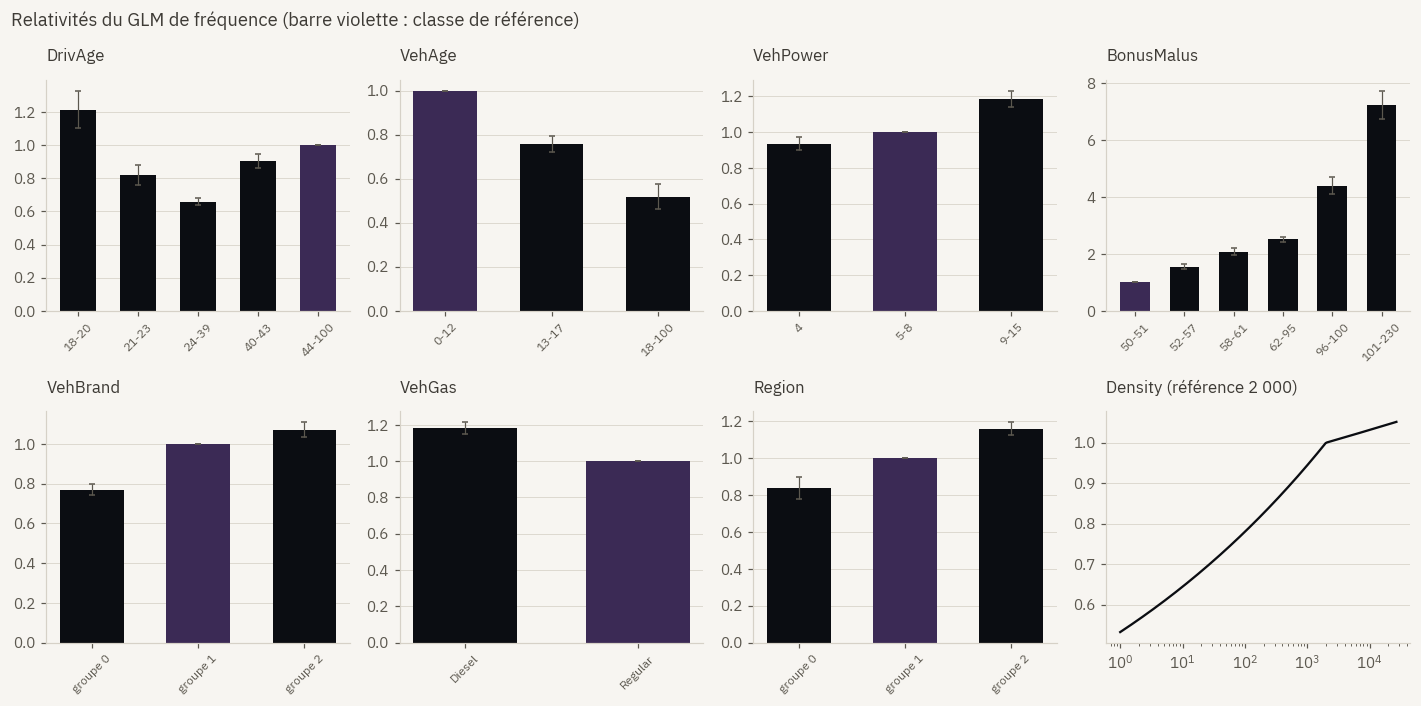

Pentes d'interaction log(BM/50) par classe d'âge du véhicule : {'log(BM/50) x VehAge[1]': np.float64(0.279), 'log(BM/50) x VehAge[2]': np.float64(0.699)}
Fréquence de référence : 0.0335


In [19]:
############################ Relativités du GLM retenu, intervalle de confiance à 95 %
def libelles(v):
    ref, niveaux = refs_glm[v]
    if spec_retenue[v][0] == "coupe":
        bornes = spec_retenue[v][1]
        bas = [int(app[v].min())] + [b + 1 for b in bornes]
        haut = bornes + [int(app[v].max())]
        return {n: f"{bas[n]}-{haut[n]}" if bas[n] != haut[n] else f"{bas[n]}" for n in niveaux}
    if spec_retenue[v][0] == "groupe":
        return {n: f"groupe {n}" for n in niveaux}
    return {n: str(n) for n in niveaux}

def relativites(modele, noms, refs, v):
    ref, niveaux = refs[v]
    lignes = []
    for n in niveaux:
        if n == ref:
            lignes.append((n, 1.0, 1.0, 1.0))
        else:
            j = noms.index(f"{v}[{n}]")
            b, e = modele.params[j], modele.bse[j]
            lignes.append((n, np.exp(b), np.exp(b - 1.96 * e), np.exp(b + 1.96 * e)))
    return pd.DataFrame(lignes, columns = ["niveau", "rel", "bas", "haut"]).set_index("niveau")

fig, axes = plt.subplots(2, 4, figsize = (13, 6.5))
for ax, v in zip(axes.flat, spec_retenue):
    r = relativites(glm, noms_glm, refs_glm, v)
    etiquettes = [libelles(v)[n] for n in r.index]
    ax.bar(range(len(r)), r["rel"], color = [VIOLET if x == 1 else INK for x in r["rel"]], width = 0.6)
    ax.errorbar(range(len(r)), r["rel"], yerr = [r["rel"] - r["bas"], r["haut"] - r["rel"]], fmt = "none", ecolor = GREY2, capsize = 2, linewidth = 0.8)
    ax.set_xticks(range(len(r)), etiquettes, rotation = 45, fontsize = 8)
    ax.set_title(v, fontsize = 11)
    ax.grid(axis = "y", color = RULE, linewidth = 0.5)
    ax.set_axisbelow(True)
ax = axes.flat[7]
grille = np.exp(np.linspace(0, np.log(27000), 200))
ax.plot(grille, np.exp(glm.params[noms_glm.index("log(Density)")] * np.log(grille)
                       + glm.params[noms_glm.index("log(Density) au-delà de 2 000")] * np.maximum(np.log(grille) - LN2000, 0)) / 2000 ** glm.params[noms_glm.index("log(Density)")],
        color = INK)
ax.set_xscale("log"); ax.set_title("Density (référence 2 000)", fontsize = 11); ax.grid(axis = "y", color = RULE, linewidth = 0.5)
fig.suptitle("Relativités du GLM de fréquence (barre violette : classe de référence)", x = 0.01, ha = "left", fontsize = 12)
fig.tight_layout()
plt.show()
pentes_bm = {n: round(glm.params[noms_glm.index(n)], 3) for n in noms_glm if n.startswith("log(BM/50)")}
print("Pentes d'interaction log(BM/50) par classe d'âge du véhicule :", pentes_bm)
print(f"Fréquence de référence : {np.exp(glm.params[0]):.4f}")

<div class="nt-section" id="part_5">
  <span class="nt-n">05</span>
  <span class="nt-t">L'EBM face au GLM</span>
</div>

<p class="nt-lede">Le GLM est la référence. L'EBM est une modélisation concurrente, jugée par
rapport à lui sur la déviance de Poisson de l'échantillon test, qui n'a servi ni à l'ajustement
ni au découpage. Une variante sans contrainte de monotonie mesure ce que coûte l'exigence d'un
bonus-malus croissant.</p>

In [20]:
############################ Variante : EBM sans contrainte, puis effet principal du bonus-malus rendu croissant
t0 = time.time()
ebm_libre = ExplainableBoostingRegressor(
    feature_names = VARIABLES, feature_types = TYPES, objective = "poisson_deviance",
    interactions = 10, n_jobs = 1, random_state = GRAINE)
ebm_libre.fit(app[VARIABLES], y_app, init_score = off_app)
deviance_libre = deviance(y_test, ebm_libre.predict(test[VARIABLES]) * test["Exposure"].values)
paires_libres = ebm_libre.term_names_[len(VARIABLES):]
ebm_libre.monotonize("BonusMalus", increasing = True)
print(f"Ajusté en {time.time() - t0:.0f} s ; interactions retenues : {paires_libres}")

############################ Déviances de Poisson moyennes sur l'échantillon test (x 100)
mu_const = np.exp(off_test) * y_app.sum() / app["Exposure"].sum()
X0_test, _, _ = matrice(test, spec_retenue, refs0, continues = densite)
comparaison = pd.Series({
    "Fréquence constante": deviance(y_test, mu_const),
    "GLM sans interaction": deviance(y_test, np.exp(X0_test @ sans_interaction.params + off_test)),
    "GLM retenu (avec BM x VehAge)": deviance(y_test, mu_glm_test),
    "EBM, bonus-malus contraint": deviance(y_test, ebm.predict(test[VARIABLES]) * test["Exposure"].values),
    "EBM sans contrainte": deviance_libre,
    "EBM sans contrainte, effet principal BM rendu croissant": deviance(y_test, ebm_libre.predict(test[VARIABLES]) * test["Exposure"].values),
}).round(3)
comparaison.to_frame("Déviance test x 100")

Ajusté en 821 s ; interactions retenues : ['VehPower & DrivAge', 'VehPower & VehBrand', 'VehAge & DrivAge', 'VehAge & BonusMalus', 'VehAge & Density', 'VehAge & Region', 'DrivAge & BonusMalus', 'BonusMalus & VehBrand', 'BonusMalus & Density', 'BonusMalus & Region']


,Déviance test x 100
Fréquence constante,25.013
GLM sans interaction,23.747
GLM retenu (avec BM x VehAge),23.734
"EBM, bonus-malus contraint",23.747
EBM sans contrainte,23.418
"EBM sans contrainte, effet principal BM rendu croissant",23.602


<p class="nt-caption">Déviance de Poisson moyenne sur l'échantillon
test, multipliée par cent. Plus bas vaut mieux.</p>

<p>Trois enseignements. Le premier est que le GLM tient : 23,73 contre 23,75 pour
l'EBM contraint, alors que le second a choisi lui-même ses intervalles et dix interactions. Le
découpage construit en partie 03 ne coûte donc rien face à un découpage automatique.

Le deuxième est que l'EBM sans contrainte descend à 23,42, et l'on voit immédiatement d'où
vient le gain : cinq de ses dix interactions font intervenir le bonus-malus, avec l'âge du
véhicule, l'âge du conducteur, la marque, la densité et la région, alors que l'EBM contraint
n'en retient aucune. La bibliothèque exclut en effet des interactions toute variable soumise à
une contrainte de monotonie, afin de garantir la croissance globale du score.

Le troisième est le prix de cette contrainte. Par rapport à une fréquence constante, à 25,01,
le tarif complet gagne 1,28 point de déviance. L'EBM libre en gagne 0,32 de plus, soit un quart
du total. Mais une fois son effet principal rendu croissant, il ne conserve que 23,60, c'est-à-dire
moins de la moitié de son avance. Le reste du gain n'est pas transposable dans un tarif qui doit
rester croissant en fonction du coefficient réglementaire.</p>

<div class="nt-section" id="part_6">
  <span class="nt-n">06</span>
  <span class="nt-t">Le coût moyen</span>
</div>

<p class="nt-lede">Le coût moyen se modélise sur les seuls sinistres. Les montants extrêmes
sont écrêtés au quantile de 99,5 pour cent et la charge retirée est réaffectée uniformément par
un chargement. Reste à décider si le coût moyen doit être segmenté ou constant : la décision se
prend par validation croisée sur l'apprentissage, jamais sur le test.</p>

In [21]:
############################ Base des sinistres : un montant par sinistre, polices d'apprentissage
sinistres = montants.merge(base[["IDpol", "Test", "Exposure"] + VARIABLES], on = "IDpol")
sin_app = sinistres[~sinistres["Test"]].reset_index(drop = True)
sin_test = sinistres[sinistres["Test"]].reset_index(drop = True)
SEUIL_GRAVE = sin_app["ClaimAmount"].quantile(0.995)
CHARGEMENT = sin_app["ClaimAmount"].sum() / sin_app["ClaimAmount"].clip(upper = SEUIL_GRAVE).sum()
sin_app["Cout"] = sin_app["ClaimAmount"].clip(upper = SEUIL_GRAVE)
sin_test["Cout"] = sin_test["ClaimAmount"].clip(upper = SEUIL_GRAVE)
print(f"{nombre(len(sin_app))} sinistres en apprentissage ; seuil d'écrêtement {nombre(SEUIL_GRAVE)} EUR ; "
      f"{(sin_app['ClaimAmount'] > SEUIL_GRAVE).sum()} sinistres écrêtés ; chargement uniforme {CHARGEMENT:.3f}")

############################ Validation croisée : coût constant contre coût segmenté (GLM gamma)
SPEC_COUT = {k: f for k, f in spec_retenue.items()}
def cont_cout(d): return np.log(d["Density"].values)[:, None], ["log(Density)"]
def deviance_gamma(y, mu): return 2 * np.mean(-np.log(y / mu) + (y - mu) / mu)
identifiants = sin_app["IDpol"].unique()
blocs = []
for numero, (i_app, i_val) in enumerate(KFold(5, shuffle = True, random_state = GRAINE).split(identifiants), 1):
    a = sin_app[sin_app["IDpol"].isin(identifiants[i_app])]
    b = sin_app[sin_app["IDpol"].isin(identifiants[i_val])]
    Xa, _, ra = matrice(a, SPEC_COUT, continues = cont_cout)
    Xb, _, _ = matrice(b, SPEC_COUT, ra, continues = cont_cout)
    gamma = sm.GLM(a["Cout"].values, Xa, family = sm.families.Gamma(sm.families.links.Log())).fit()
    blocs.append({"Bloc": numero, "Constant": deviance_gamma(b["Cout"].values, np.full(len(b), a["Cout"].mean())),
                  "Segmenté": deviance_gamma(b["Cout"].values, np.exp(Xb @ gamma.params))})
blocs = pd.DataFrame(blocs).set_index("Bloc")
blocs["Gain du segmenté (%)"] = 100 * (1 - blocs["Segmenté"] / blocs["Constant"])
blocs.loc["Moyenne"] = blocs.mean()
blocs.round(4)

23 599 sinistres en apprentissage ; seuil d'écrêtement 33 625 EUR ; 118 sinistres écrêtés ; chargement uniforme 1.348


,Constant,Segmenté,Gain du segmenté (%)
Bloc,,,
1,1.1745,1.1674,0.6056
2,1.2036,1.2033,0.0286
3,1.1375,1.1353,0.1887
4,1.1948,1.1864,0.7037
5,1.1451,1.1400,0.4397
Moyenne,1.1711,1.1665,0.3933


<p class="nt-caption">Déviance gamma sur le bloc de validation, cinq blocs
constitués par police.</p>

<p>Le coût segmenté gagne sur les cinq blocs, mais très peu : 0,39 pour cent de
déviance en moyenne, entre 0,03 et 0,70 pour cent selon le bloc. Sur l'échantillon test, qui
n'a servi à aucune décision, l'ordre s'inverse : 1,199 pour le coût constant, 1,208 pour le GLM
gamma et 1,202 pour l'EBM gamma. Un gain aussi faible, qui ne se reproduit pas hors échantillon,
ne justifie pas de segmenter, d'autant qu'une part importante des montants est forfaitaire. Le
coût moyen retenu est donc constant : 1 682 EUR écrêtés, chargés à 1,348, soit 2 267 EUR par
sinistre et une prime pure moyenne de 167,9 EUR par an.</p>

In [22]:
############################ Contrôle sur le test : constant, GLM gamma, EBM gamma
Xa, _, ra = matrice(sin_app, SPEC_COUT, continues = cont_cout)
Xt, _, _ = matrice(sin_test, SPEC_COUT, ra, continues = cont_cout)
gamma_complet = sm.GLM(sin_app["Cout"].values, Xa, family = sm.families.Gamma(sm.families.links.Log())).fit()
ebm_cout = ExplainableBoostingRegressor(feature_names = VARIABLES, feature_types = TYPES, objective = "gamma_deviance",
                                        n_jobs = 1, random_state = GRAINE)
ebm_cout.fit(sin_app[VARIABLES], sin_app["Cout"])
print(pd.Series({
    "Constant": deviance_gamma(sin_test["Cout"].values, np.full(len(sin_test), sin_app["Cout"].mean())),
    "GLM gamma": deviance_gamma(sin_test["Cout"].values, np.exp(Xt @ gamma_complet.params)),
    "EBM gamma": deviance_gamma(sin_test["Cout"].values, ebm_cout.predict(sin_test[VARIABLES]))}).round(4).to_string())

############################ Coût moyen retenu et prime pure
COUT_MOYEN = sin_app["Cout"].mean() * CHARGEMENT
print(f"\nCoût moyen écrêté {nombre(sin_app['Cout'].mean())} EUR x chargement {CHARGEMENT:.3f} = {nombre(COUT_MOYEN)} EUR par sinistre")
print(f"Prime pure moyenne (apprentissage) : {nombre(COUT_MOYEN * y_app.sum() / app['Exposure'].sum(), 1)} EUR par an")

Constant     1.1990
GLM gamma    1.2075
EBM gamma    1.2020

Coût moyen écrêté 1 682 EUR x chargement 1.348 = 2 267 EUR par sinistre
Prime pure moyenne (apprentissage) : 167.9 EUR par an


<div class="nt-section" id="part_7">
  <span class="nt-n">07</span>
  <span class="nt-t">Le graphe causal et sa validation</span>
</div>

<p class="nt-lede">Séparer ce qui revient au bonus-malus demande de dire comment les variables
se déterminent entre elles. Un graphe orienté acyclique rend cette hypothèse explicite et
vérifiable : il n'est pas lu dans les données, il est écrit par le métier, puis confronté à
elles par les indépendances conditionnelles qu'il implique.</p>

<div class="nt-limit">
  <span class="nt-label">POURQUOI AUCUN ALGORITHME DE DÉCOUVERTE N'EST UTILISÉ</span>
  <p>Les algorithmes de découverte causale essayés sur ces données en amont de ce carnet,
  DirectLiNGAM et FCI, ont produit des orientations contraires à la chronologie et des sorties
  qui changeaient avec le découpage des variables. Ils ne sont donc pas repris ici. La démarche suivie est celle de Côté, Côté et Charpentier : un graphe
  d'expert, puis des tests.</p>
</div>

<h4>LE GRAPHE, VARIABLE PAR VARIABLE</h4>

<table>
<thead><tr><th>Strate</th><th>Variable</th><th>Causes retenues</th><th>Justification</th></tr></thead>
<tbody>
<tr><td>Conducteur</td><td>DrivAge</td><td>aucune</td><td>Caractéristique acquise à la naissance :
rien dans le portefeuille ne la précède.</td></tr>
<tr><td>Conducteur</td><td>U, non observée</td><td>aucune</td><td>La conduite réelle, jamais mesurée.
Elle est supposée indépendante de l'âge : ce que l'âge change dans la conduite passe par la
flèche directe de l'âge vers les sinistres.</td></tr>
<tr><td>Lieu</td><td>Region, Density</td><td>DrivAge, et Region pour Density</td><td>Le lieu de
résidence dépend du moment de la vie, études, activité, retraite. La région conditionne les
densités accessibles.</td></tr>
<tr><td>Véhicule</td><td>VehBrand</td><td>DrivAge, Region</td><td>Le choix d'une marque dépend
du budget et de l'âge, et du réseau de distribution présent dans la région.</td></tr>
<tr><td>Véhicule</td><td>VehAge, VehGas</td><td>DrivAge, Density, VehBrand</td><td>L'ancienneté
du véhicule et le carburant suivent le budget, le kilométrage attendu et la gamme de la
marque.</td></tr>
<tr><td>Véhicule</td><td>VehPower</td><td>DrivAge, VehBrand, VehGas</td><td>La puissance
fiscale se choisit dans le catalogue de la marque, et dépend du carburant.</td></tr>
<tr><td>Historique et durée</td><td>BonusMalus</td><td>DrivAge, Region, Density, U</td><td>Le
coefficient résume les sinistres passés et l'ancienneté de conduite. L'âge borne le bonus
accessible, 0,95 par année sans sinistre depuis 1,00, le plancher de 0,50 n'étant atteint
qu'après treize ans. L'environnement de circulation et la conduite U déterminent les sinistres
passés. Le coefficient est le témoin de U : c'est la raison pour laquelle il prédit si
bien.</td></tr>
<tr><td>Historique et durée</td><td>Exposure</td><td>aucune</td><td>Durée d'observation,
traitée en offset.</td></tr>
<tr><td>Sinistres</td><td>ClaimNb</td><td>toutes les caractéristiques, BonusMalus, Exposure,
U</td><td>La flèche du bonus-malus vers le nombre de sinistres représente l'effet
d'incitation : un assuré au bonus maximal déclare moins volontiers un petit sinistre.</td></tr>
<tr><td>Sinistres</td><td>ClaimAmount</td><td>ClaimNb</td><td>Le coût moyen est traité comme
constant, partie 06.</td></tr>
</tbody>
</table>

<p class="nt-caption">Les flèches claires du graphe représentent les liens de toutes les
caractéristiques vers ClaimNb, communes à toutes les variantes.</p>

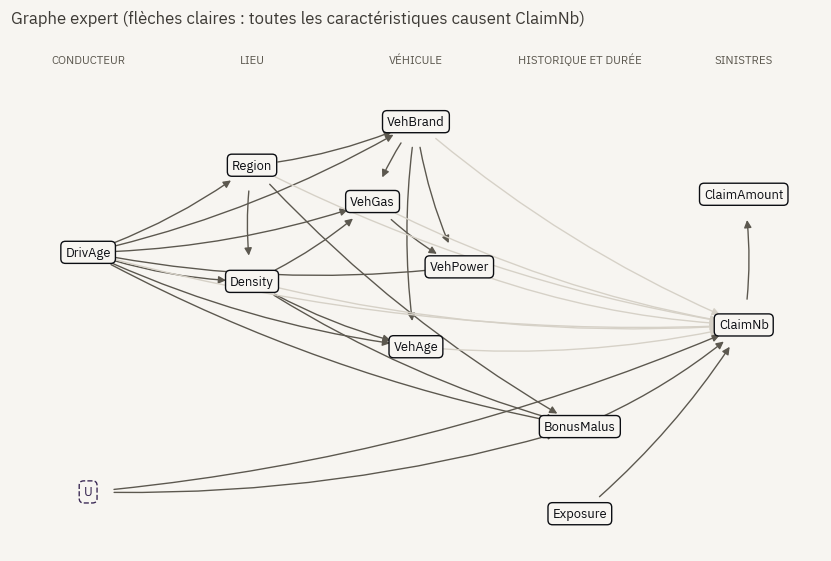

In [23]:
############################ Graphe expert et graphe corrigé
STRATES = {"conducteur": 0.0, "lieu": 1.7, "véhicule": 3.4, "historique et durée": 5.1, "sinistres": 6.8}
POSITIONS = {"DrivAge": (0.0, 3.6), "U": (0.0, 0.3), "Region": (1.7, 4.8), "Density": (1.7, 3.2),
             "VehBrand": (3.4, 5.4), "VehGas": (2.95, 4.3), "VehPower": (3.85, 3.4), "VehAge": (3.4, 2.3),
             "BonusMalus": (5.1, 1.2), "Exposure": (5.1, 0.0), "ClaimNb": (6.8, 2.6), "ClaimAmount": (6.8, 4.4)}
EXPERT = [("DrivAge", "Region"), ("DrivAge", "Density"), ("Region", "Density"),
          ("DrivAge", "VehBrand"), ("DrivAge", "VehPower"), ("DrivAge", "VehAge"), ("DrivAge", "VehGas"),
          ("Region", "VehBrand"), ("Density", "VehGas"), ("Density", "VehAge"),
          ("VehBrand", "VehPower"), ("VehBrand", "VehGas"), ("VehBrand", "VehAge"), ("VehGas", "VehPower"),
          ("DrivAge", "BonusMalus"), ("Region", "BonusMalus"), ("Density", "BonusMalus"), ("U", "BonusMalus"),
          ("U", "ClaimNb"), ("BonusMalus", "ClaimNb"), ("Exposure", "ClaimNb"), ("ClaimNb", "ClaimAmount")]
VERS_SINISTRES = ["DrivAge", "Region", "Density", "VehBrand", "VehPower", "VehAge", "VehGas"]

def dessiner(ax, aretes, ajouts = (), bidirigees = (), titre = ""):
    for (a, b) in aretes + [(v, "ClaimNb") for v in VERS_SINISTRES]:
        couleur = VIOLET if (a, b) in ajouts else (RULE if b == "ClaimNb" and a in VERS_SINISTRES else GREY2)
        ax.annotate("", xy = POSITIONS[b], xytext = POSITIONS[a],
                    arrowprops = dict(arrowstyle = "-|>", color = couleur, linewidth = 1.6 if (a, b) in ajouts else 0.9,
                                      shrinkA = 17, shrinkB = 17, connectionstyle = "arc3,rad=0.08"))
    for (a, b) in bidirigees:
        ax.annotate("", xy = POSITIONS[b], xytext = POSITIONS[a],
                    arrowprops = dict(arrowstyle = "<|-|>", color = VIOLET, linewidth = 1.6, linestyle = "--",
                                      shrinkA = 17, shrinkB = 17, connectionstyle = "arc3,rad=0.3"))
    for noeud, (x, y) in POSITIONS.items():
        latent = noeud == "U"
        ax.text(x, y, noeud, ha = "center", va = "center", fontsize = 8.5,
                color = VIOLET if latent else INK,
                bbox = dict(boxstyle = "round,pad=0.35", facecolor = IVORY, edgecolor = VIOLET if latent else INK,
                            linestyle = "--" if latent else "-", linewidth = 0.9))
    for strate, x in STRATES.items():
        ax.text(x, 6.2, strate.upper(), ha = "center", fontsize = 7.5, color = GREY2)
    ax.set_xlim(-0.8, 7.6); ax.set_ylim(-0.5, 6.5); ax.axis("off"); ax.set_title(titre, fontsize = 11)

fig, ax = plt.subplots(figsize = (9.5, 6))
dessiner(ax, EXPERT, titre = "Graphe expert (flèches claires : toutes les caractéristiques causent ClaimNb)")
plt.show()

<h4>COMMENT LES IMPLICATIONS SONT TESTÉES</h4>

<p>Une absence de flèche est une hypothèse forte : elle implique une indépendance
conditionnelle. Chaque implication est testée par régression : la variable réponse est
expliquée par les seules variables de conditionnement, puis par ces variables plus celle dont
le lien est supposé absent. La mesure retenue est le R carré partiel, c'est-à-dire la part de
variance résiduelle que la seconde variable explique en plus. Les p-valeurs sont toutes
minuscules à cette taille d'échantillon : elles ne servent pas à décider. Les dernières lignes
donnent l'ordre de grandeur de liens que le métier retient, pour calibrer le seuil.</p>

<p class="nt-caption">Une indépendance impliquée est jugée contredite lorsque le R carré
partiel atteint 0,10 pour cent, c'est-à-dire l'ordre de grandeur des liens les plus faibles que
le graphe retient par ailleurs.</p>

In [24]:
############################ Tests des indépendances conditionnelles impliquées par le graphe expert
REPONSES = {"BonusMalus": np.log(base["BonusMalus"]), "VehPower": base["VehPower"].astype(float),
            "VehAge": np.log1p(base["VehAge"]), "VehGas": (base["VehGas"] == "Diesel").astype(float),
            "Density": np.log(base["Density"])}
CODAGES = {"DrivAge": base["DrivAge"].clip(upper = 85), "Density": pd.qcut(base["Density"], 20, duplicates = "drop").cat.codes,
           "Region": base["Region"], "VehBrand": base["VehBrand"], "VehGas": base["VehGas"],
           "VehPower": base["VehPower"].clip(upper = 12), "VehAge": pd.cut(base["VehAge"], [-1, 0, 2, 5, 10, 15, 200]).cat.codes,
           "BonusMalus": classes(base["BonusMalus"].values, BM_CLASSES)}
def indicatrices(v): return pd.get_dummies(CODAGES[v], drop_first = True, dtype = np.float32).values
def somme_carres(y, X):
    # équations normales : la matrice de dessin compte plus de six cent mille lignes
    gram = X.T @ X
    second = X.T @ y
    coef = np.linalg.lstsq(gram, second, rcond = None)[0]
    return float(y @ y - 2 * coef @ second + coef @ gram @ coef)
def r2_partiel(reponse, autre, conditionnement):
    y = REPONSES[reponse].values.astype(np.float64)
    X0 = np.column_stack([np.ones(len(y), dtype = np.float32)] + [indicatrices(c) for c in conditionnement])
    Xa = indicatrices(autre)
    X1 = np.column_stack([X0, Xa])
    s0, s1 = somme_carres(y, X0.astype(np.float64)), somme_carres(y, X1.astype(np.float64))
    ddl1, ddl2 = Xa.shape[1], len(y) - X1.shape[1]
    return 100 * (s0 - s1) / s0, loi_f.sf(((s0 - s1) / ddl1) / (s1 / ddl2), ddl1, ddl2)

IMPLIQUEES = [("BonusMalus", "VehBrand", ["DrivAge", "Region", "Density"]),
              ("BonusMalus", "VehPower", ["DrivAge", "Region", "Density"]),
              ("BonusMalus", "VehAge", ["DrivAge", "Region", "Density"]),
              ("BonusMalus", "VehGas", ["DrivAge", "Region", "Density"]),
              ("VehPower", "Region", ["DrivAge", "Density", "VehBrand", "VehGas"]),
              ("VehAge", "Region", ["DrivAge", "Density", "VehBrand"]),
              ("VehGas", "Region", ["DrivAge", "Density", "VehBrand"]),
              ("Density", "VehBrand", ["DrivAge", "Region"]),
              ("VehGas", "VehAge", ["DrivAge", "Density", "VehBrand"]),
              ("VehPower", "Density", ["DrivAge", "VehBrand", "VehGas"]),
              ("VehPower", "VehAge", ["DrivAge", "VehBrand", "VehGas", "Density"])]
REPERES = [("Density", "DrivAge", ["Region"]), ("VehAge", "DrivAge", ["Density", "VehBrand"]),
           ("VehPower", "DrivAge", ["VehBrand", "VehGas"]), ("BonusMalus", "Density", ["DrivAge", "Region"]),
           ("BonusMalus", "DrivAge", [])]
SEUIL_R2 = 0.10
lignes_ci = []
for groupe, liste in [("indépendance impliquée", IMPLIQUEES), ("lien expert (repère)", REPERES)]:
    for reponse, autre, cond in liste:
        r2, p = r2_partiel(reponse, autre, cond)
        verdict = ("contredite" if r2 >= SEUIL_R2 else "compatible") if groupe.startswith("ind") else ""
        lignes_ci.append({"Nature": groupe, "Couple": f"{reponse} et {autre}", "Sachant": ", ".join(cond) or "rien",
                          "R² partiel (%)": round(r2, 3), "p": f"{p:.0e}", "Verdict": verdict})
pd.DataFrame(lignes_ci).set_index(["Nature", "Couple"])

Sachant  R² partiel (%)       p     Verdict
Nature                 Couple                                                                                        
indépendance impliquée BonusMalus et VehBrand            DrivAge, Region, Density           0.054   8e-72  compatible
                       BonusMalus et VehPower            DrivAge, Region, Density           0.155  2e-218  contredite
                       BonusMalus et VehAge              DrivAge, Region, Density           0.706   0e+00  contredite
                       BonusMalus et VehGas              DrivAge, Region, Density           0.039   2e-58  compatible
                       VehPower et Region      DrivAge, Density, VehBrand, VehGas           0.231   0e+00  contredite
                       VehAge et Region                DrivAge, Density, VehBrand           0.674   0e+00  contredite
                       VehGas et Region                DrivAge, Density, VehBrand           0.316   0e+00  contredite
                       Density et VehBrand                        DrivAge, Region           0.386   0e+00  contredite
                       VehGas et VehAge                DrivAge, Density, VehBrand           3.261   0e+00  contredite
                       VehPower et Density              DrivAge, VehBrand, VehGas           0.161  3e-216  contredite
                       VehPower et VehAge      DrivAge, VehBrand, VehGas, Density           0.361   0e+00  contredite
lien expert (repère)   Density et DrivAge                                  Region           0.233   0e+00            
                       VehAge et DrivAge                        Density, VehBrand           0.528   0e+00            
                       VehPower et DrivAge                       VehBrand, VehGas           0.746   0e+00            
                       BonusMalus et Density                      DrivAge, Region           1.393   0e+00            
                       BonusMalus et DrivAge                                 rien          39.827   0e+00

<p>Deux implications sur onze résistent. Le bonus-malus est bien indépendant de la
marque et du carburant une fois l'âge, la région et la densité connus : 0,054 et 0,039 pour
cent de variance résiduelle, soit quatre à six fois moins que le plus faible lien que le graphe
retient par ailleurs, 0,23 pour cent entre densité et âge. Les neuf autres sont contredites, à des degrés très inégaux. La plus
forte lie le carburant à l'âge du véhicule, 3,26 pour cent : la diésélisation du parc s'est
faite par vagues et l'année de mise en circulation détermine en partie la motorisation.
Viennent les liens du lieu vers le véhicule, de 0,16 à 0,67 pour cent, qui traduisent des parcs
automobiles régionaux différents. Reste le point qui compte pour la suite : le bonus-malus
demeure associé à l'âge du véhicule, 0,71 pour cent, et à la puissance, 0,16 pour cent, une
fois l'âge du conducteur, la région et la densité pris en compte.</p>

<div class="nt-accent">
  <span class="nt-label">CE QUE LA CORRECTION CHANGE POUR LA SUITE</span>
  <div class="nt-t">Les variables véhicule portent une part du signal du bonus-malus</div>
  <p>La chronologie interdit de faire causer les sinistres passés par le
  véhicule d'aujourd'hui, et le coefficient ne choisit pas la voiture. Deux lectures restent.
  La conduite non observée agit à la fois sur le coefficient et sur le choix du véhicule, un
  conducteur prudent ne prenant pas la même voiture qu'un autre. Ou bien le véhicule, détenu
  depuis plusieurs années, a contribué aux sinistres qui ont formé le coefficient. Les deux
  produisent une association non causale, représentée par une flèche bidirigée en pointillé,
  comme le font les auteurs de l'article lorsqu'une variable est marginalisée. La conséquence
  est directe : l'âge du véhicule et la puissance portent une part du signal du coefficient, et
  un tarif qui renonce au coefficient le reconstituera partiellement à travers elles. La partie
  08 mesure cette part.</p>
</div>

Liens ajoutés : [('Region', 'VehPower'), ('Region', 'VehAge'), ('Region', 'VehGas'), ('Density', 'VehBrand'), ('VehAge', 'VehGas'), ('Density', 'VehPower'), ('VehAge', 'VehPower')]
Associations bidirigées avec le bonus-malus : [('VehAge', 'BonusMalus'), ('VehPower', 'BonusMalus')]


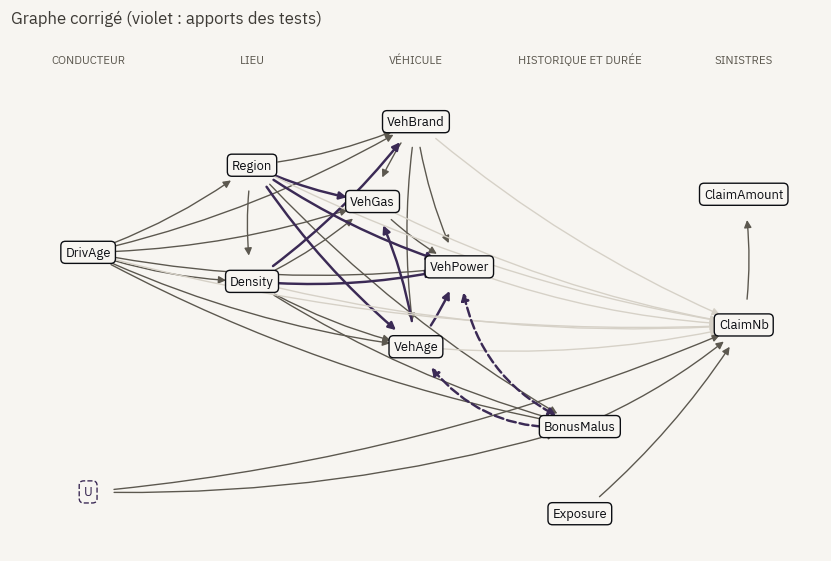

In [25]:
############################ Graphe corrigé
AJOUTS = [("Region", "VehPower"), ("Region", "VehAge"), ("Region", "VehGas"), ("Density", "VehBrand"),
          ("VehAge", "VehGas"), ("Density", "VehPower"), ("VehAge", "VehPower")]
AJOUTS = [a for a in AJOUTS if any(l["Verdict"] == "contredite" and set(l["Couple"].split(" et ")) == set(a) for l in lignes_ci)]
BIDIRIGEES = [(a, b) for a, b in [("VehAge", "BonusMalus"), ("VehPower", "BonusMalus"), ("VehBrand", "BonusMalus"), ("VehGas", "BonusMalus")]
              if any(l["Verdict"] == "contredite" and set(l["Couple"].split(" et ")) == {a, b} for l in lignes_ci)]
print("Liens ajoutés :", AJOUTS)
print("Associations bidirigées avec le bonus-malus :", BIDIRIGEES)
fig, ax = plt.subplots(figsize = (9.5, 6))
dessiner(ax, EXPERT + AJOUTS, ajouts = AJOUTS, bidirigees = BIDIRIGEES, titre = "Graphe corrigé (violet : apports des tests)")
plt.show()

<h4>LE POINT QUI COMMANDE LA SUITE : LE BONUS-MALUS EST UN COLLISIONNEUR</h4>

<p>Deux flèches entrent dans le coefficient depuis deux causes que le graphe tient pour
indépendantes : l'âge, qui borne le bonus accessible, et la conduite non observée U. Au sens de
la définition 2 de l'article, le coefficient est donc un collisionneur entre l'âge et U.</p>

<p>La conséquence est mécanique. Tant qu'on ne conditionne pas sur le coefficient, le chemin
qui va de l'âge aux sinistres en passant par le coefficient et par U est fermé. Dès qu'on
compare des assurés à coefficient égal, il s'ouvre. Un coefficient de 0,76 est la trajectoire
normale de cinq années sans sinistre ; chez un conducteur de cinquante ans, il signale des
sinistres récents. À coefficient égal, l'âge ne mesure plus l'âge : il mesure l'historique.
Cette implication se vérifie directement sur les fréquences.</p>

In [26]:
############################ À coefficient égal, l'âge change de sens
etiq_age = np.array([libelles("DrivAge")[n] for n in range(len(AGE_CLASSES) + 1)])
etiq_bm = np.array([libelles("BonusMalus")[n] for n in range(len(BM_CLASSES) + 1)])
cadre = pd.DataFrame({"Coefficient": etiq_bm[classes(app["BonusMalus"].values, BM_CLASSES)],
                      "Âge": etiq_age[classes(app["DrivAge"].values, AGE_CLASSES)],
                      "e": app["Exposure"].values, "n": y_app})
def frequences(groupes):
    somme = cadre.groupby(groupes)[["e", "n"]].sum()
    return (100 * somme["n"] / somme["e"]).where(somme["e"] >= 300)
collision = frequences(["Coefficient", "Âge"]).unstack("Âge")
collision.loc["tous coefficients"] = frequences(["Âge"])
collision = collision.reindex(index = list(etiq_bm) + ["tous coefficients"], columns = list(etiq_age))
collision.round(1).astype(object).where(collision.notna(), "")

Âge,18-20,21-23,24-39,40-43,44-100
Coefficient,,,,,
50-51,,,4.2,5.4,5.3
52-57,,,5.5,7.5,9.8
58-61,,,7.2,11.1,13.4
62-95,13.4,9.7,9.6,13.1,16.5
96-100,36.0,25.5,18.1,18.2,17.8
101-230,,41.2,30.9,,37.6
tous coefficients,23.6,15.1,7.5,7.2,6.9


<p class="nt-caption">Fréquence annuelle en pour cent, par classe de coefficient et classe
d'âge, apprentissage. Cases vides : moins de 300 années-police.</p>

<p>Tous coefficients confondus, la fréquence baisse avec l'âge, de 23,6 sinistres pour cent
années-police chez les 18-20 ans à 6,9 chez les 44 ans et plus. À l'intérieur d'une même classe
de coefficient, l'ordre s'inverse au-delà de 24 ans : dans la classe 62-95, les 44 ans et plus
déclarent 16,5 sinistres pour cent années-police contre 9,6 pour les 24-39 ans, et le même
renversement se lit dans les classes 52-57 et 58-61. Ce n'est pas un effet de l'âge. À
cinquante ans, ne pas avoir atteint le plancher signifie presque toujours avoir eu des
sinistres ; entre 24 et 39 ans, c'est souvent la simple conséquence d'un permis récent.</p>

<div class="nt-accent">
  <span class="nt-label">CE QUE CELA CHANGE POUR LA SUITE</span>
  <div class="nt-t">Une relativité d'âge à coefficient égal n'est pas une part propre</div>
  <p>Le best estimate et la prime aware mesurent l'effet de l'âge à coefficient égal. Ils
  héritent donc de cette sélection : ils écrasent l'écart entre jeunes et anciens conducteurs,
  au point de donner aux 24-39 ans une fréquence inférieure d'un tiers à celle des 44 ans et
  plus, relativité de 0,66 en partie 04, alors que leur fréquence observée est plus élevée.
  Pour mesurer ce que le bonus-malus prend réellement à l'âge, la partie 08 ne compare donc pas
  le tarif sans coefficient à un tarif à coefficient égal, mais à un tarif estimé sous le
  coefficient réglementaire, tel qu'il sera appliqué.</p>
</div>

<div class="nt-section" id="part_8">
  <span class="nt-n">08</span>
  <span class="nt-t">Les primes et le double comptage</span>
</div>

<p class="nt-lede">Côté, Côté et Charpentier classent les tarifs selon la position du score dans
le graphe. Quatre des cinq familles se calculent ici, en notant D le bonus-malus et X les autres
variables. Une cinquième prime, propre au cadre français, répond directement à la question du
double comptage.</p>

<div class="nt-list">
  <div class="nt-item">
    <span class="nt-n">01</span>
    <div>
      <p class="nt-h">Best estimate</p>
      <p class="nt-d">L'espérance de la fréquence sachant X et D : c'est le GLM retenu en partie
      04. Il utilise toute l'information disponible.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">02</span>
    <div>
      <p class="nt-h">Unaware</p>
      <p class="nt-d">L'espérance sachant X seulement : le même tarif ajusté sans le
      bonus-malus. Il ne l'utilise pas, mais le reconstitue indirectement à travers les
      variables qui lui sont liées. Ses relativités sont les effets totaux de chaque
      variable.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">03</span>
    <div>
      <p class="nt-h">Aware, ou prix sans discrimination</p>
      <p class="nt-d">La moyenne du best estimate sur la loi marginale du bonus-malus, à X fixé.
      Le coefficient entre dans l'estimation mais ne figure pas dans le prix. Ses relativités
      sont celles d'une comparaison à coefficient égal, avec le biais de sélection montré en
      partie 07.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">04</span>
    <div>
      <p class="nt-h">Corrective</p>
      <p class="nt-d">Un tarif construit sur la seule composante de X indépendante du
      bonus-malus, obtenue en centrant chaque colonne de la matrice de tarif par classe de
      coefficient, selon la projection de Komiyama et Shimao et de Frees et Huang.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">05</span>
    <div>
      <p class="nt-h">Prime de référence sous coefficient réglementaire</p>
      <p class="nt-d">Le tarif sans bonus-malus, estimé avec le logarithme du coefficient
      réellement appliqué en offset, comme on le fait pour l'exposition. Elle répond à la
      question opérationnelle : que doit facturer la prime de référence, sachant que le
      coefficient réglementaire la multipliera ensuite ?</p>
    </div>
  </div>
</div>

<div class="nt-limit">
  <span class="nt-label">DEUX DIFFÉRENCES AVEC LE CADRE DE L'ARTICLE</span>
  <p>Dans l'article, la variable protégée D précède et cause les variables tarifaires X. Ici,
  la chronologie impose l'inverse pour l'âge : c'est l'âge qui borne le coefficient. Les
  quatre familles gardent leur définition statistique, mais l'écart entre elles se lit comme un
  double comptage entre le tarif et le coefficient, pas comme une discrimination. Ensuite, D
  n'est pas une variable à exclure du prix : il y entre par un barème réglementaire que
  l'assureur ne choisit pas. La prime à livrer est donc la cinquième, estimée sous ce barème,
  et non la prime aware, qui suppose que D ne sera pas facturé.</p>
</div>

In [27]:
############################ Les quatre primes de fréquence
MARGINALE_BM = app.groupby("BonusMalus")["Exposure"].sum() / app["Exposure"].sum()

############################ 1. Best estimate : le GLM retenu
def prime_best(d):
    X, _, _ = matrice(d, spec_retenue, refs_glm, continues = continues_retenues)
    return np.exp(X @ glm.params)

############################ 2. Unaware : même tarif, sans le bonus-malus
spec_sans_bm = {k: f for k, f in spec_retenue.items() if k != "BonusMalus"}
X_u, noms_u, refs_u = matrice(app, spec_sans_bm, continues = densite)
glm_unaware = poisson(y_app, X_u, off_app)
def prime_unaware(d):
    X, _, _ = matrice(d, spec_sans_bm, refs_u, continues = densite)
    return np.exp(X @ glm_unaware.params)

############################ 3. Aware : moyenne du best estimate sur la loi marginale du bonus-malus
def facteur_bm(d):
    ref, niveaux = refs_glm["BonusMalus"]
    effets = pd.Series(0.0, index = MARGINALE_BM.index)
    k = classes(MARGINALE_BM.index.values, BM_CLASSES)
    for n in niveaux:
        if n != ref:
            effets[k == n] = glm.params[noms_glm.index(f"BonusMalus[{n}]")]
    pentes = np.zeros(len(d))
    for nom in noms_glm:
        if nom.startswith("log(BM/50)"):
            n = int(nom.split("[")[1].rstrip("]"))
            pentes[classe_vehicule(d) == n] = glm.params[noms_glm.index(nom)]
    lnbm = np.log(MARGINALE_BM.index.values / 50)
    return np.exp(effets.values[None, :] + pentes[:, None] * lnbm[None, :]) @ MARGINALE_BM.values

def effet_bm_individuel(d):
    X_sans, _, _ = matrice(d, spec_sans_bm, {k: refs_glm[k] for k in spec_sans_bm}, continues = densite)
    colonnes = [noms_glm.index(n) for n in ["constante"] + [n for n in noms_glm if not n.startswith(("BonusMalus", "log(BM/50)"))][1:]]
    return X_sans, colonnes

def prime_aware_brute(d):
    X_sans, colonnes = effet_bm_individuel(d)
    return np.exp(X_sans @ glm.params[colonnes]) * facteur_bm(d)
EQUILIBRE_AWARE = y_app.sum() / (prime_aware_brute(app) * app["Exposure"].values).sum()
def prime_aware(d): return EQUILIBRE_AWARE * prime_aware_brute(d)

############################ 4. Corrective : composantes de X centrées par classe de bonus-malus
def centrer(d, X, moyennes = None):
    k = classes(d["BonusMalus"].values, BM_CLASSES)
    if moyennes is None:
        poids = d["Exposure"].values
        moyennes = {n: np.average(X[k == n], axis = 0, weights = poids[k == n]) for n in np.unique(k)}
    Xc = X.copy()
    for n, m in moyennes.items():
        Xc[k == n, 1:] -= m[1:]
    return Xc, moyennes
X_c, MOYENNES = centrer(app, X_u)
glm_corrective = poisson(y_app, X_c, off_app)
def prime_corrective(d):
    X, _, _ = matrice(d, spec_sans_bm, refs_u, continues = densite)
    return np.exp(centrer(d, X, MOYENNES)[0] @ glm_corrective.params)

PRIMES = {"Best estimate": prime_best, "Unaware": prime_unaware, "Aware": prime_aware, "Corrective": prime_corrective}

############################ 5. Prime de référence estimée sous le coefficient réglementaire (offset)
coef_app = app["BonusMalus"].values / 100
glm_reference = poisson(y_app, X_u, off_app + np.log(coef_app))
def prime_reference(d):
    X, _, _ = matrice(d, spec_sans_bm, refs_u, continues = densite)
    return np.exp(X @ glm_reference.params)

############################ Tarifs réellement facturés : prime de référence multipliée par le coefficient
BASES = {"Unaware x coefficient": prime_unaware, "Aware x coefficient": prime_aware, "Référence x coefficient": prime_reference}
EQUILIBRES = {nom: y_app.sum() / (f(app) * coef_app * app["Exposure"].values).sum() for nom, f in BASES.items()}
def facturee(nom, d): return EQUILIBRES[nom] * BASES[nom](d) * d["BonusMalus"].values / 100
age_app = classes(app["DrivAge"].values, AGE_CLASSES)
def ae_par_age(prime):
    attendu = pd.Series(prime * app["Exposure"].values).groupby(age_app).sum()
    return pd.Series(y_app).groupby(age_app).sum() / attendu
lignes_facture = {"Best estimate (repère)": {"Déviance test x 100": deviance(y_test, mu_glm_test),
                                            **{f"O/A {libelles('DrivAge')[k]}": r for k, r in ae_par_age(prime_best(app)).items()}}}
for nom in BASES:
    lignes_facture[nom] = {"Déviance test x 100": deviance(y_test, facturee(nom, test) * test["Exposure"].values),
                           **{f"O/A {libelles('DrivAge')[k]}": r for k, r in ae_par_age(facturee(nom, app)).items()}}
print(f"Coefficient d'équilibre de la prime aware : {EQUILIBRE_AWARE:.4f}")
print("Coefficients d'équilibre des tarifs facturés :", {k: round(v, 4) for k, v in EQUILIBRES.items()})
bilan = pd.DataFrame({nom: {
    "Déviance test x 100": deviance(y_test, f(test) * test["Exposure"].values),
    "Sinistres attendus / observés (apprentissage)": (f(app) * app["Exposure"].values).sum() / y_app.sum(),
    "Prime pure moyenne (EUR/an)": COUT_MOYEN * np.average(f(app), weights = app["Exposure"])} for nom, f in PRIMES.items()}).T
display(bilan.round(3))
pd.DataFrame(lignes_facture).T.round(3)

Coefficient d'équilibre de la prime aware : 0.9739
Coefficients d'équilibre des tarifs facturés : {'Unaware x coefficient': np.float64(1.6815), 'Aware x coefficient': np.float64(1.7495), 'Référence x coefficient': np.float64(1.0)}


,Déviance test x 100,Sinistres attendus / observés (apprentissage),Prime pure moyenne (EUR/an)
Best estimate,23.734,1.0,167.927
Unaware,24.531,1.0,167.927
Aware,24.895,1.0,167.927
Corrective,24.672,1.0,167.927


,Déviance test x 100,O/A 18-20,O/A 21-23,O/A 24-39,O/A 40-43,O/A 44-100
Best estimate (repère),23.734,1.000,1.000,1.000,1.000,1.000
Unaware x coefficient,24.113,0.631,0.666,0.920,1.068,1.116
Aware x coefficient,24.171,1.455,1.414,1.178,0.966,0.893
Référence x coefficient,24.060,1.000,1.000,1.000,1.000,1.000


<p class="nt-caption">Premier tableau : les quatre familles, calées sur le même total de
sinistres. Second tableau : le tarif réellement payé, prime de référence multipliée par le
coefficient, pour trois choix de prime de référence, avec le rapport entre sinistres observés
et attendus (O/A) par classe d'âge sur l'apprentissage.</p>

<p>Les quatre familles donnent la même prime pure moyenne, 167,9 EUR par an, la prime aware
recevant pour cela un coefficient d'équilibre de 0,974, correction de niveau pour laquelle Côté,
Côté et Charpentier renvoient à Lindholm et ses coauteurs. Sur le test, le classement est net :
23,73 pour le best estimate, 24,53 pour l'unaware, 24,67 pour la corrective et 24,90 pour
l'aware, contre 25,01 pour une fréquence constante. Sur les 1,28 point de déviance que le tarif
complet gagne sur une prime unique, 0,80 disparaît lorsque le coefficient n'est plus facturé
mais reste reconstitué par les autres variables, et 1,16 lorsqu'il n'est ni facturé ni
reconstitué : le bonus-malus porte l'essentiel du pouvoir discriminant du tarif.</p>

<p>Le second tableau mesure le double comptage, que les quatre familles seules ne montrent
pas. Multiplier la prime unaware par le coefficient fait payer aux 18-20 ans 58 pour cent de plus
que leurs sinistres, rapport O/A de 0,63, et aux 44 ans et plus 10 pour cent de moins :
l'absence de bonus des jeunes est facturée deux fois, par leur relativité d'âge et par leur
coefficient. Multiplier la prime aware par le coefficient commet l'erreur inverse : avec un
rapport de 1,46, les 18-20 ans ne paient que 69 pour cent de leurs sinistres. La prime de
référence estimée sous le coefficient équilibre chaque classe d'âge par construction, et c'est
aussi, des trois tarifs facturés, celui qui prédit le mieux le test, 24,06 contre 24,11 et
24,17.</p>

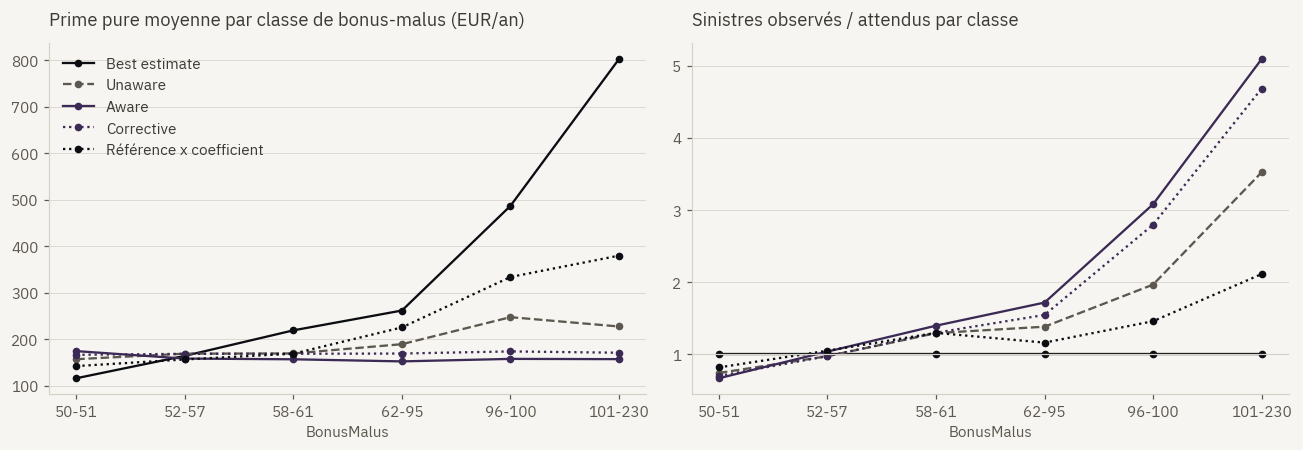

50-51   52-57   58-61   62-95  96-100  101-230
Prime pure (EUR/an) Best estimate            117.00  165.00  220.00  262.00  487.00   803.00
                    Unaware                  158.00  169.00  170.00  190.00  248.00   228.00
                    Aware                    175.00  159.00  157.00  153.00  158.00   158.00
                    Corrective               167.00  169.00  169.00  170.00  174.00   171.00
                    Référence x coefficient  143.00  157.00  169.00  226.00  334.00   380.00
Observés / attendus Best estimate              1.00    1.00    1.00    1.00    1.00     1.00
                    Unaware                    0.74    0.97    1.29    1.38    1.97     3.52
                    Aware                      0.67    1.04    1.40    1.72    3.08     5.09
                    Corrective                 0.70    0.97    1.30    1.55    2.80     4.69
                    Référence x coefficient    0.82    1.05    1.30    1.16    1.46     2.11

In [28]:
############################ Lecture par classe de bonus-malus : niveau de prime et adéquation
app_classes = classes(app["BonusMalus"].values, BM_CLASSES)
etiquettes_bm = [libelles("BonusMalus")[n] for n in range(len(BM_CLASSES) + 1)]
fig, axes = plt.subplots(1, 2, figsize = (12, 4.2))
styles = {"Best estimate": (INK, "-"), "Unaware": (GREY2, "--"), "Aware": (VIOLET, "-"), "Corrective": (VIOLET, ":"),
          "Référence x coefficient": (INK, ":")}
courbes = dict(PRIMES, **{"Référence x coefficient": lambda d: facturee("Référence x coefficient", d)})
niveaux_bm, ratios_bm = {}, {}
for nom, f in courbes.items():
    prime = f(app)
    cadre = pd.DataFrame({"k": app_classes, "e": app["Exposure"].values, "p": prime * app["Exposure"].values, "n": y_app})
    somme = cadre.groupby("k")[["e", "p", "n"]].sum()
    niveaux_bm[nom], ratios_bm[nom] = (somme["p"] / somme["e"]) * COUT_MOYEN, somme["n"] / somme["p"]
    couleur, trait = styles[nom]
    axes[0].plot(range(len(somme)), (somme["p"] / somme["e"]) * COUT_MOYEN, color = couleur, linestyle = trait, marker = "o", markersize = 4, label = nom)
    axes[1].plot(range(len(somme)), somme["n"] / somme["p"], color = couleur, linestyle = trait, marker = "o", markersize = 4, label = nom)
axes[0].set_title("Prime pure moyenne par classe de bonus-malus (EUR/an)")
axes[1].set_title("Sinistres observés / attendus par classe")
axes[1].axhline(1, color = RULE, linewidth = 0.8)
for ax in axes:
    ax.set_xticks(range(len(etiquettes_bm)), etiquettes_bm)
    ax.set_xlabel("BonusMalus")
    ax.grid(axis = "y", color = RULE, linewidth = 0.5)
axes[0].legend(frameon = False)
fig.tight_layout()
plt.show()
lecture_bm = pd.concat({"Prime pure (EUR/an)": pd.DataFrame(niveaux_bm).T.round(0), "Observés / attendus": pd.DataFrame(ratios_bm).T.round(2)})
lecture_bm.columns = etiquettes_bm
lecture_bm

<p class="nt-caption">À gauche, le niveau de prime par classe de bonus-malus. À droite, le
rapport entre sinistres observés et sinistres attendus : un tarif adéquat par classe se tient
sur la ligne horizontale. Le tableau donne les valeurs tracées.</p>

<p>À gauche, la prime best estimate va de 117 EUR par an dans la classe de bonus maximal à
803 EUR chez les majorés, un rapport proche de sept. La prime unaware n'en reconstitue qu'une
fraction, de 158 à 248 EUR. La corrective est plate, de 167 à 174 EUR : c'est l'objet de sa
construction, un prix indépendant du coefficient. L'aware ne l'est pas et va même à rebours,
175 EUR au bonus maximal contre 153 à 159 EUR ailleurs : les 44 ans et plus, qui peuplent la
classe de bonus maximal, y reçoivent une relativité supérieure à celle des 24-39 ans. C'est le
biais du collisionneur, visible cette fois dans la prime.</p>

<p>À droite, le revers. Les trois primes qui ne facturent pas le coefficient encaissent chez
les majorés 3,5 à 5,1 fois moins que leurs sinistres : le critère d'indépendance est approché,
celui de suffisance est violé, c'est l'arbitrage que décrivent Côté, Côté et Charpentier. La
prime de référence multipliée par le coefficient se tient plus près de l'équilibre, de 0,82 au
bonus maximal à 2,11 chez les majorés, sans l'atteindre : le barème réglementaire est moins
pentu que le risque. Ce reste est discuté avec la dernière figure.</p>

In [29]:
############################ Relativités par classe : totale, à coefficient égal, sous coefficient réglementaire
def rel_table(modele, noms, refs, v):
    return relativites(modele, noms, refs, v)["rel"]
def rel_densite(modele, noms, d):
    b1, b2 = modele.params[noms.index("log(Density)")], modele.params[noms.index("log(Density) au-delà de 2 000")]
    return np.exp(b1 * (np.log(d) - LN2000) + b2 * max(np.log(d) - LN2000, 0))
lignes_parts = []
for v in spec_sans_bm:
    best = rel_table(glm, noms_glm, refs_glm, v)
    if v == INTERACTION:
        cadre_v = pd.DataFrame({"k": classe_vehicule(app)}).drop_duplicates().sort_values("k")
        facteurs = facteur_bm(app.loc[cadre_v.index])
        aware = best * pd.Series(facteurs / facteurs[list(cadre_v["k"]).index(refs_glm[v][0])], index = cadre_v["k"].values)
    else:
        aware = best
    unaware, reference = rel_table(glm_unaware, noms_u, refs_u, v), rel_table(glm_reference, noms_u, refs_u, v)
    corrective = rel_table(glm_corrective, noms_u, refs_u, v)
    for n in best.index:
        lignes_parts.append({"Variable": v, "Classe": libelles(v)[n], "Unaware (totale)": unaware[n],
                             "Aware (à coefficient égal)": aware[n], "Référence sous coefficient": reference[n],
                             "Part facturée par le coefficient": unaware[n] / reference[n], "Corrective": corrective[n]})
for valeur in [20, 200, 20000]:
    u, a, r, c = (rel_densite(m, nm, valeur) for m, nm in
                  [(glm_unaware, noms_u), (glm, noms_glm), (glm_reference, noms_u), (glm_corrective, noms_u)])
    lignes_parts.append({"Variable": "Density", "Classe": f"{nombre(valeur)} hab/km² (réf. 2 000)",
                         "Unaware (totale)": u, "Aware (à coefficient égal)": a, "Référence sous coefficient": r,
                         "Part facturée par le coefficient": u / r, "Corrective": c})
coef_moyen = pd.Series(app["BonusMalus"].values * app["Exposure"].values).groupby(age_app).sum() / pd.Series(app["Exposure"].values).groupby(age_app).sum() / 100
print("Coefficient moyen pondéré par l'exposition : portefeuille", round(np.average(app["BonusMalus"], weights = app["Exposure"]) / 100, 3), "|",
      " ; ".join(f"{libelles('DrivAge')[k]} : {m:.3f}" for k, m in coef_moyen.items()))
parts = pd.DataFrame(lignes_parts).set_index(["Variable", "Classe"]).round(3)
parts

Coefficient moyen pondéré par l'exposition : portefeuille 0.578 | 18-20 : 0.940 ; 21-23 : 0.893 ; 24-39 : 0.644 ; 40-43 : 0.554 ; 44-100 : 0.531


Unaware (totale)  Aware (à coefficient égal)  Référence sous coefficient  Part facturée par le coefficient  Corrective
Variable Classe                                                                                                                                             
DrivAge  18-20                                   3.502                       1.213                       1.981                             1.768       1.702
         21-23                                   2.162                       0.819                       1.294                             1.671       0.826
         24-39                                   1.049                       0.660                       0.867                             1.210       0.632
         40-43                                   1.018                       0.905                       0.976                             1.043       0.921
         44-100                                  1.000                       1.000                       1.000                             1.000       1.000
VehAge   0-12                                    1.000                       1.000                       1.000                             1.000       1.000
         13-17                                   0.859                       0.811                       0.835                             1.028       0.814
         18-100                                  0.632                       0.621                       0.621                             1.019       0.627
VehPower 4                                       0.947                       0.935                       0.938                             1.009       0.928
         5-8                                     1.000                       1.000                       1.000                             1.000       1.000
         9-15                                    1.139                       1.187                       1.159                             0.982       1.182
VehBrand groupe 0                                0.802                       0.771                       0.787                             1.020       0.761
         groupe 1                                1.000                       1.000                       1.000                             1.000       1.000
         groupe 2                                1.087                       1.072                       1.080                             1.006       1.075
VehGas   Diesel                                  1.193                       1.182                       1.193                             1.000       1.189
         Regular                                 1.000                       1.000                       1.000                             1.000       1.000
Region   groupe 0                                0.792                       0.837                       0.808                             0.980       0.842
         groupe 1                                1.000                       1.000                       1.000                             1.000       1.000
         groupe 2                                1.170                       1.161                       1.172                             0.999       1.167
Density  20 hab/km² (réf. 2 000)                 0.585                       0.683                       0.624                             0.938       0.690
         200 hab/km² (réf. 2 000)                0.765                       0.826                       0.790                             0.969       0.831
         20 000 hab/km² (réf. 2 000)             1.174                       1.045                       1.120                             1.048       1.069

<p class="nt-caption">Pour chaque classe : la relativité du tarif sans coefficient (effet total),
celle du tarif à coefficient égal, celle de la prime de référence estimée sous le coefficient
réglementaire, leur rapport, qui est la part que le coefficient facture déjà, et la relativité
corrective. Pour la densité, relativités à 20, 200 et 20 000 habitants par km² contre 2 000.</p>

<p>Le résultat central tient dans les colonnes trois et quatre. Chez les 18-20 ans, la
relativité unaware de 3,50 se décompose en 1,77, que le coefficient facture déjà, et 1,98, que
la prime de référence doit encore facturer. Le premier facteur vient de ce que ces conducteurs
sont en moyenne au coefficient 0,94 quand le portefeuille est à 0,58 ; en échelle logarithmique,
il représente 45 pour cent de leur surprime. Le second est du même ordre que le plafond de la
surprime des conducteurs novices, 100 pour cent de la prime de référence selon l'article A121-1-1 du Code des assurances : un repère de marché qui situe la mesure. Pour les 21-23 ans,
2,16 se décompose en 1,67 et 1,29 ; pour les 24-39 ans, 1,05 se décompose en 1,21 et 0,87, car
leur coefficient moyen, 0,64, dépasse celui des 44 ans et plus, 0,53.</p>

<p>La relativité aware, 1,21 chez les 18-20 ans, sous-estime nettement ce qui reste à facturer.
Elle traduit le biais de sélection du collisionneur, pas une part propre : elle ne peut pas servir
à dire ce que le bonus-malus prend à l'âge.</p>

<p>Hors âge, la part facturée par le coefficient reste faible : 3 pour cent au plus pour le
véhicule, la marque et la région, 6 pour cent pour la densité en zone très rurale. Les tests de
la partie 07 avaient montré une association résiduelle entre le coefficient et le véhicule :
elle existe, mais ne pèse presque rien dans le tarif. Le double comptage est un problème d'âge
du conducteur. La corrective, enfin, compare les assurés à l'intérieur de chaque classe de
coefficient sans corriger le niveau des classes : ses relativités ne se lisent pas comme un
effet propre, et elle n'a pas d'usage tarifaire ici.</p>

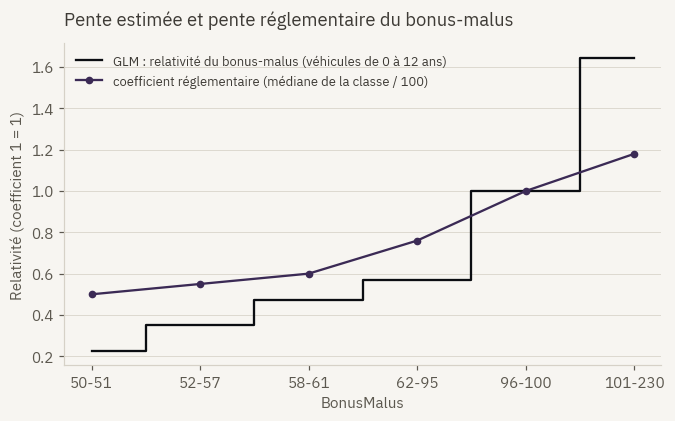

,Médiane BonusMalus,Relativité GLM (100 = 1),Coefficient réglementaire
Classe,,,
50-51,50.0,0.23,0.50
52-57,55.0,0.35,0.55
58-61,60.0,0.47,0.60
62-95,76.0,0.57,0.76
96-100,100.0,1.00,1.00
101-230,118.0,1.64,1.18


Prime de référence du profil type, avant coefficient : 334.6 EUR par an


Prime moyenne facturée au portefeuille : 167.9 EUR par an


,Best estimate (repère),Unaware x coefficient,Aware x coefficient,Référence x coefficient
"profil type, 50 ans, coefficient 0,50",143.0,152.0,185.0,167.0
"profil type, 50 ans, coefficient 1,00",627.0,303.0,369.0,335.0
"même véhicule, 30 ans, coefficient 0,76",236.0,242.0,185.0,220.0
"même véhicule, 19 ans, coefficient 1,00",760.0,1063.0,448.0,663.0


In [30]:
############################ Le bonus-malus estimé face au coefficient réglementaire
ref, niveaux = refs_glm["BonusMalus"]
app_classes = classes(app["BonusMalus"].values, BM_CLASSES)
effets = [1.0 if n == ref else np.exp(glm.params[noms_glm.index(f"BonusMalus[{n}]")]) for n in niveaux]
centres = [app.loc[app_classes == n, "BonusMalus"].median() for n in niveaux]
rel_estimee = np.array(effets) / effets[list(niveaux).index(classes(np.array([100]), BM_CLASSES)[0])]
fig, ax = plt.subplots(figsize = (7, 3.8))
ax.step(range(len(niveaux)), rel_estimee, where = "mid", color = INK, label = "GLM : relativité du bonus-malus (véhicules de 0 à 12 ans)")
ax.plot(range(len(niveaux)), np.array(centres) / 100, color = VIOLET, marker = "o", markersize = 4, label = "coefficient réglementaire (médiane de la classe / 100)")
ax.set_xticks(range(len(niveaux)), etiquettes_bm)
ax.set_xlabel("BonusMalus"); ax.set_ylabel("Relativité (coefficient 1 = 1)")
ax.set_title("Pente estimée et pente réglementaire du bonus-malus")
ax.legend(frameon = False, fontsize = 8.5); ax.grid(axis = "y", color = RULE, linewidth = 0.5)
plt.show()
display(pd.DataFrame({"Classe": etiquettes_bm, "Médiane BonusMalus": centres, "Relativité GLM (100 = 1)": rel_estimee.round(2),
                      "Coefficient réglementaire": np.array(centres) / 100}).set_index("Classe"))

############################ Prime de référence livrée : profil type et quatre assurés
def modalite_de_reference(v): return next(m for m, g in GROUPES[v].items() if g == refs_glm[v][0])
profil_type = {"DrivAge": 50, "VehAge": 5, "VehPower": 6, "VehBrand": modalite_de_reference("VehBrand"), "VehGas": "Regular",
               "Region": modalite_de_reference("Region"), "Density": 2000, "Exposure": 1.0}
assures = pd.DataFrame([dict(profil_type, BonusMalus = 50), dict(profil_type, BonusMalus = 100),
                        dict(profil_type, DrivAge = 30, BonusMalus = 76), dict(profil_type, DrivAge = 19, BonusMalus = 100)],
                       index = ["profil type, 50 ans, coefficient 0,50", "profil type, 50 ans, coefficient 1,00",
                                "même véhicule, 30 ans, coefficient 0,76", "même véhicule, 19 ans, coefficient 1,00"])
prime_ref_type = COUT_MOYEN * EQUILIBRES["Référence x coefficient"] * prime_reference(assures.iloc[[0]])[0]
print(f"Prime de référence du profil type, avant coefficient : {nombre(prime_ref_type, 1)} EUR par an")
print(f"Prime moyenne facturée au portefeuille : {nombre(COUT_MOYEN * np.average(facturee('Référence x coefficient', app), weights = app['Exposure']), 1)} EUR par an")
pd.DataFrame({"Best estimate (repère)": COUT_MOYEN * prime_best(assures),
              **{nom: COUT_MOYEN * facturee(nom, assures) for nom in BASES}}, index = assures.index).round(0)

<p class="nt-caption">En haut, la pente que le GLM estime pour le bonus-malus et la pente du
barème, toutes deux ramenées à 1 au coefficient 1,00. En bas, la prime pure annuelle facturée à
quatre assurés selon la prime de référence retenue, le best estimate servant de repère.</p>

<p>La figure explique pourquoi la prime aware ne peut pas servir de prime de référence. La
pente que le GLM estime pour le bonus-malus est plus raide que le barème : 0,23 contre 0,50 au
bonus maximal, 1,64 contre 1,18 chez les majorés. Le barème ne se modifie pas ; c'est donc la
prime de référence qui doit être estimée sous le barème, et non l'inverse. Deux réserves
accompagnent cette lecture : la classe 96-100 mélange des novices, qui partent au coefficient
d'origine, et des conducteurs redescendus après un sinistre ; la pente estimée reflète aussi la
composition du portefeuille de cet assureur.</p>

<p>La prime de référence livrée est la cinquième prime. Pour le profil type, conducteur de 50
ans, véhicule de 5 ans et de 6 CV d'une marque du groupe 1, essence, région du groupe 1 et
densité de 2 000 habitants par km², elle vaut 334,6 EUR par an avant coefficient, soit 167 EUR au
coefficient 0,50 ; la moyenne facturée au portefeuille reste 167,9 EUR. Pour un conducteur de 19
ans au coefficient 1,00, elle conduit à 663 EUR, contre 1 063 EUR avec la prime unaware, qui
compte deux fois son absence de bonus, et 448 EUR avec la prime aware, qui la sous-estime.</p>

<p>Reste l'écart par classe de coefficient, de 0,82 à 2,11 en sinistres observés sur attendus :
à barème fixé, la classe de bonus maximal paie davantage que ses sinistres, toutes les autres
moins, les majorés deux fois moins. Il ne vient pas de la prime de référence mais du barème, moins
pentu que le risque. Peut-il se corriger sans compter deux fois le coefficient ? La cellule
suivante l'estime.</p>


In [31]:
############################ Le bonus-malus réintroduit sous le barème : relativité résiduelle de coefficient
spec_residuel = {**spec_sans_bm, "BonusMalus": spec_retenue["BonusMalus"]}
k_100 = classes(np.array([100]), BM_CLASSES)[0]
_, _, refs_r = matrice(app, spec_residuel, continues = densite)
refs_r["BonusMalus"] = (k_100, refs_r["BonusMalus"][1])   # relativités lues contre la classe du coefficient d'origine
X_r, noms_r, _ = matrice(app, spec_residuel, refs_r, continues = densite)
glm_residuel = poisson(y_app, X_r, off_app + np.log(coef_app))
def prime_residuelle(d):
    X, _, _ = matrice(d, spec_residuel, refs_r, continues = densite)
    return np.exp(X @ glm_residuel.params)
NOM_RESIDUEL = "Référence et relativité résiduelle x coefficient"
BASES[NOM_RESIDUEL] = prime_residuelle
EQUILIBRES[NOM_RESIDUEL] = y_app.sum() / (prime_residuelle(app) * coef_app * app["Exposure"].values).sum()

############################ Relativité résiduelle par classe, 96-100 = 1
r_bm = relativites(glm_residuel, noms_r, refs_r, "BonusMalus")

############################ Adéquation par classe de coefficient sur l'échantillon test
k_test = classes(test["BonusMalus"].values, BM_CLASSES)
def oa_test(nom):
    attendu = pd.Series(facturee(nom, test) * test["Exposure"].values).groupby(k_test).sum()
    return pd.Series(y_test).groupby(k_test).sum() / attendu
lecture = pd.DataFrame({"Relativité résiduelle (96-100 = 1)": r_bm["rel"], "IC 95 % bas": r_bm["bas"], "IC 95 % haut": r_bm["haut"],
                        "Sinistres test": pd.Series(y_test).groupby(k_test).sum(),
                        "O/A test, référence x coefficient": oa_test("Référence x coefficient"),
                        "O/A test, avec relativité résiduelle": oa_test(NOM_RESIDUEL)})
lecture.index = [libelles("BonusMalus")[n] for n in lecture.index]
lecture.index.name = "Classe de coefficient"
display(lecture.round(2))
pd.Series({"Best estimate (repère)": deviance(y_test, mu_glm_test),
           "Référence x coefficient": deviance(y_test, facturee("Référence x coefficient", test) * test["Exposure"].values),
           NOM_RESIDUEL: deviance(y_test, facturee(NOM_RESIDUEL, test) * test["Exposure"].values)}).round(3).to_frame("Déviance test x 100")


,Relativité résiduelle (96-100 = 1),IC 95 % bas,IC 95 % haut,Sinistres test,"O/A test, référence x coefficient","O/A test, avec relativité résiduelle"
Classe de coefficient,,,,,,
50-51,0.42,0.39,0.44,1147,0.80,0.98
52-57,0.59,0.55,0.64,172,0.92,0.87
58-61,0.74,0.68,0.80,138,1.35,1.04
62-95,0.72,0.67,0.76,811,1.09,0.94
96-100,1.00,1.00,1.00,153,1.64,1.13
101-230,1.39,1.28,1.51,120,2.08,1.00


,Déviance test x 100
Best estimate (repère),23.734
Référence x coefficient,24.060
Référence et relativité résiduelle x coefficient,23.768


<p class="nt-caption">En haut, la relativité résiduelle de chaque classe de coefficient, estimée avec le
coefficient réglementaire en offset et ramenée à 1 dans la classe 96-100, puis les sinistres
observés sur attendus par classe sur l'échantillon test. En bas, la déviance test des tarifs
facturés, le best estimate servant de repère.</p>

<p>Le coefficient peut revenir dans le tarif sans être compté deux fois. Estimé avec le coefficient
réglementaire en offset, comme l'exposition, le GLM ne mesure plus l'effet du bonus-malus mais
seulement ce que le barème n'en capte pas : 0,42 au bonus maximal, intervalle de 0,39 à 0,44, et
1,39 chez les majorés, de 1,28 à 1,51, contre 1 au coefficient d'origine. Ce sont les ordres de
grandeur qu'annonçait la figure précédente, rapport de la pente estimée à celle du barème, 0,23
sur 0,50 et 1,64 sur 1,18.</p>

<p>Multipliée par le coefficient, cette prime retrouve presque le best estimate : 23,77 de déviance
test contre 23,73, quand la prime de référence seule restait à 24,06. Elle récupère 0,29 des
0,33 point perdus ; le reste tient à l'interaction avec l'âge du véhicule, absente de cette
spécification. Sur le test, les rapports observés sur attendus par classe passent d'une plage de
0,80 à 2,08 à une plage de 0,87 à 1,13, sur des effectifs de 120 à 1 147 sinistres par classe.
En apprentissage, cet équilibre par classe serait mécanique ; le contrôle qui le confirme sans
l'imposer est celui des déciles, plus bas.</p>

<div class="nt-accent">
  <span class="nt-label">UNE QUESTION DE CONFORMITÉ, PAS DE MODÉLISATION</span>
  <div class="nt-t">L'écart se corrige techniquement, son usage reste à instruire</div>
  <p>La relativité résiduelle ne compte rien deux fois : elle mesure ce que le barème ne capte pas.
  Ce qui la limite est réglementaire. L'annexe à l'article A121-1 du Code des assurances confie le
  traitement de l'historique de sinistres au coefficient, articles 4 et 5, et définit la prime de
  référence par des caractéristiques techniques, article 2 ; l'article A121-1-2 énumère de façon
  limitative les majorations applicables en plus du barème. Introduire cette relativité dans un
  tarif est donc une décision de conformité, à instruire avec un juriste. Le carnet la mesure, il
  ne tranche pas son admissibilité.</p>
</div>


<h4>TROIS CONTRÔLES DE ROBUSTESSE</h4>

<p>La prime de référence porte la conclusion du carnet. Trois questions restent à lui poser :
l'écart entre les relativités d'âge est-il plus grand que l'incertitude d'estimation ? Le tarif
facturé est-il calibré hors de l'échantillon qui a servi à l'ajuster, au-delà des classes que le
GLM équilibre par construction ? Un modèle d'apprentissage ferait-il mieux sur le même problème ?</p>


In [32]:
############################ 1. Intervalles de confiance à 95 % des relativités des plus jeunes
ic = []
for nom, modele, noms, refs in [("Unaware (totale)", glm_unaware, noms_u, refs_u), ("Aware (à coefficient égal)", glm, noms_glm, refs_glm),
                                ("Référence sous coefficient", glm_reference, noms_u, refs_u)]:
    r = relativites(modele, noms, refs, "DrivAge")
    for n in r.index[:2]:
        ic.append({"Classe": libelles("DrivAge")[n], "Prime": nom, "Relativité": r.loc[n, "rel"], "IC 95 % bas": r.loc[n, "bas"], "IC 95 % haut": r.loc[n, "haut"]})
display(pd.DataFrame(ic).set_index(["Classe", "Prime"]).round(2))


,,Relativité,IC 95 % bas,IC 95 % haut
Classe,Prime,,,
18-20,Unaware (totale),3.50,3.21,3.82
21-23,Unaware (totale),2.16,2.02,2.31
18-20,Aware (à coefficient égal),1.21,1.11,1.33
21-23,Aware (à coefficient égal),0.82,0.76,0.88
18-20,Référence sous coefficient,1.98,1.82,2.16
21-23,Référence sous coefficient,1.29,1.21,1.38


In [33]:
############################ 2. Prédictions hors bloc : validation croisée à 5 blocs sur l'apprentissage
offset_coef = off_app + np.log(coef_app)
X_best, _, _ = matrice(app, spec_retenue, refs_glm, continues = continues_retenues)
AJUSTEMENTS = {"Unaware x coefficient": (X_u, off_app), "Best estimate": (X_best, off_app),
               "Référence x coefficient": (X_u, offset_coef), NOM_RESIDUEL: (X_r, offset_coef)}
hors_bloc = {nom: np.zeros(len(app)) for nom in AJUSTEMENTS}
for i_a, i_v in KFold(5, shuffle = True, random_state = GRAINE).split(np.arange(len(app))):
    for nom, (X, decalage) in AJUSTEMENTS.items():
        m = poisson(y_app[i_a], X[i_a], decalage[i_a])
        # le tarif unaware est ajusté sans le coefficient, puis facturé avec lui et recalé sur le bloc d'ajustement
        attendu = np.exp(X @ m.params + (offset_coef if nom == "Unaware x coefficient" else decalage))
        hors_bloc[nom][i_v] = attendu[i_v] * y_app[i_a].sum() / attendu[i_a].sum()

############################ 2a. Par classe d'âge : le double comptage hors bloc
oa_cv = pd.DataFrame({nom: pd.Series(y_app).groupby(age_app).sum() / pd.Series(hors_bloc[nom]).groupby(age_app).sum()
                      for nom in ["Unaware x coefficient", "Référence x coefficient"]}).T
oa_cv.columns = [f"O/A {libelles('DrivAge')[k]}" for k in oa_cv.columns]
display(oa_cv.round(3))

############################ 2b. Par décile de fréquence facturée : la calibration que le modèle n'impose pas
def oa_deciles(prime):
    frequence = prime / app["Exposure"].values
    ordre = np.argsort(frequence, kind = "stable")
    cumul = np.empty(len(app)); cumul[ordre] = np.cumsum(app["Exposure"].values[ordre]) / app["Exposure"].sum()
    decile = np.minimum((cumul * 10).astype(int), 9) + 1
    return pd.Series(y_app).groupby(decile).sum() / pd.Series(prime).groupby(decile).sum()
oa_dec = pd.DataFrame({nom: oa_deciles(hors_bloc[nom]) for nom in ["Best estimate", "Référence x coefficient", NOM_RESIDUEL]}).T
oa_dec.columns = [f"D{k}" for k in oa_dec.columns]
display(oa_dec.round(2))


,O/A 18-20,O/A 21-23,O/A 24-39,O/A 40-43,O/A 44-100
Unaware x coefficient,0.631,0.666,0.92,1.068,1.116
Référence x coefficient,1.001,1.000,1.00,1.000,1.000


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
Best estimate,1.06,1.01,1.04,0.94,0.98,0.97,0.96,1.03,1.02,1.00
Référence x coefficient,0.85,0.87,0.87,0.89,0.92,0.91,0.98,1.03,1.09,1.19
Référence et relativité résiduelle x coefficient,1.02,1.01,1.05,0.94,0.97,0.98,0.97,1.05,1.05,0.97


None

In [34]:
############################ 3. Un EBM challenger sur le même problème : sans bonus-malus, coefficient en offset
SANS_BM = [v for v in VARIABLES if v != "BonusMalus"]
t0 = time.time()
ebm_reference = ExplainableBoostingRegressor(
    feature_names = SANS_BM, feature_types = [t for v, t in zip(VARIABLES, TYPES) if v != "BonusMalus"],
    objective = "poisson_deviance", interactions = 10, n_jobs = 1, random_state = GRAINE)
ebm_reference.fit(app[SANS_BM], y_app, init_score = offset_coef)
print(f"EBM de référence ajusté en {time.time() - t0:.0f} s")
facteur_test = test["Exposure"].values * test["BonusMalus"].values / 100
pd.Series({"GLM de référence x coefficient": deviance(y_test, facturee("Référence x coefficient", test) * test["Exposure"].values),
           "EBM de référence x coefficient": deviance(y_test, ebm_reference.predict(test[SANS_BM]) * facteur_test)}).round(3).to_frame("Déviance test x 100")

EBM de référence ajusté en 156 s


,Déviance test x 100
GLM de référence x coefficient,24.060
EBM de référence x coefficient,24.014


<p class="nt-caption">Premier tableau : relativités des deux plus jeunes classes d'âge et leur
intervalle de confiance à 95 pour cent. Deuxième et troisième tableaux : sinistres observés sur
attendus, chaque police étant tarifée par un modèle qui ne l'a pas vue, par classe d'âge puis par
décile de fréquence facturée pondéré par l'exposition. Quatrième tableau : la prime de référence
face à un EBM ajusté sur le même problème, sur l'échantillon test.</p>

<p>L'écart entre les relativités des 18-20 ans dépasse largement l'incertitude
d'estimation : 1,98 pour la prime de référence, intervalle de 1,82 à 2,16, contre 3,50 pour
l'unaware, de 3,21 à 3,82, et 1,21 pour l'aware, de 1,11 à 1,33. Les trois intervalles sont
disjoints, et il en va de même pour les 21-23 ans.</p>

<p>Hors bloc, le double comptage se reproduit à l'identique : multipliée par le
coefficient, la prime unaware fait payer aux 18-20 ans 58 pour cent de plus que leurs sinistres,
rapport de 0,63, comme sur l'apprentissage. La ligne de la prime de référence, à 1,00, ne démontre
en revanche rien. Un GLM de Poisson à lien canonique équilibre chaque indicatrice de ses variables
sur l'échantillon d'ajustement, et comme chaque police sert à quatre ajustements sur cinq, cet
équilibre se transmet presque intégralement hors bloc.</p>

<p>Le contrôle que le modèle n'impose pas est celui des déciles. Le best estimate reste calibré sur
toute l'échelle, de 0,94 à 1,06. La prime de référence multipliée par le coefficient ne l'est pas :
le décile le moins risqué paie 18 pour cent de plus que ses sinistres, rapport de 0,85, et le plus
risqué n'en paie que 84 pour cent, rapport de 1,19. C'est l'écart du barème, vu cette fois par
niveau de risque. Avec la relativité résiduelle, la calibration revient au niveau du best
estimate, de 0,94 à 1,05.</p>

<p>Enfin, l'EBM ajusté sur le même problème ne fait guère mieux que le GLM de
référence : 24,01 contre 24,06, soit 0,05 point. Face au best estimate, l'EBM libre en gagnait
0,32 en partie 05, près de sept fois plus. Son avance venait des interactions du bonus-malus ;
dès que le coefficient est imposé par le barème, elle disparaît presque entièrement. Le GLM de
référence ne laisse presque rien sur la table.</p>


<div class="nt-section" id="part_9">
  <span class="nt-n">09</span>
  <span class="nt-t">Ce que la causalité apporte</span>
</div>

<p class="nt-lede">Le graphe n'améliore pas la prédiction : le best estimate reste le meilleur
prédicteur du test. Il sert à autre chose, décider laquelle des primes calculées répond à la
question posée. Pour la surprime des 18-20 ans, quatre chiffres coexistent, 3,50, 1,98, 1,70 et
1,21, et les données seules ne permettent pas de choisir entre eux.</p>

<div class="nt-list">
  <div class="nt-item">
    <span class="nt-n">01</span>
    <div>
      <p class="nt-h">Il dit ce que mesure chaque comparaison</p>
      <p class="nt-d">L'âge n'a pas de cause dans le graphe : sa relativité sans coefficient est
      son effet total. Le coefficient est un collisionneur entre l'âge et la conduite non
      observée : toute relativité prise à coefficient égal, celle du best estimate comme celle
      de l'aware, est biaisée par sélection. C'est la lecture habituelle d'un GLM qui contient le
      bonus-malus, et elle donne aux 24-39 ans une fréquence inférieure d'un tiers à celle des 44
      ans et plus, ce que la fréquence observée dément.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">02</span>
    <div>
      <p class="nt-h">Il écarte le mauvais estimateur</p>
      <p class="nt-d">La prime aware neutralise le coefficient par sa loi marginale, mais ses
      relativités sont prises à coefficient égal. Le graphe montre pourquoi elle ne convient pas
      ici ; le fait que le coefficient soit appliqué par barème désigne alors l'estimation sous ce
      barème. Pour un conducteur de 19 ans au coefficient 1,00, l'écart est de 448 à 663 EUR par
      an de prime pure.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">03</span>
    <div>
      <p class="nt-h">Il dit où chercher, les tests disent ce qui reste</p>
      <p class="nt-d">Les indépendances impliquées ont signalé un lien résiduel entre coefficient
      et véhicule, c'est-à-dire un chemin par lequel le tarif pouvait reconstituer le bonus-malus.
      La mesure le ramène à 3 pour cent au plus. Le graphe transforme une inquiétude générale,
      le double comptage, en une liste de chemins vérifiés un à un.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">04</span>
    <div>
      <p class="nt-h">Il rend les compromis explicites</p>
      <p class="nt-d">Aucune prime ne peut être à la fois indépendante du coefficient et juste par
      classe de coefficient. La classification de Côté, Côté et Charpentier nomme ce que chaque
      prime sacrifie : la corrective atteint l'indépendance et encaisse chez les majorés près de
      cinq fois moins que leurs sinistres, le best estimate est juste par classe et facture le
      coefficient deux fois s'il est appliqué par-dessus.</p>
    </div>
  </div>
</div>

<div class="nt-limit">
  <span class="nt-label">CE QUE LA CAUSALITÉ N'APPORTE PAS</span>
  <p>Aucun gain de pouvoir prédictif. Aucune certitude non plus : l'hypothèse qui fait du
  coefficient un collisionneur, l'indépendance entre l'âge et la conduite non observée, n'est pas
  testable, et le graphe reste un jugement d'expert que les tests peuvent contredire sans jamais
  le confirmer. Son apport est de rendre ce jugement explicite, discutable et vérifiable là où il
  peut l'être.</p>
</div>

<div class="nt-section" id="part_10">
  <span class="nt-n">10</span>
  <span class="nt-t">Limites</span>
</div>

<div class="nt-list">
  <div class="nt-item">
    <span class="nt-n">01</span>
    <div>
      <p class="nt-h">Le graphe reste une hypothèse</p>
      <p class="nt-d">Les tests peuvent contredire une absence de flèche, jamais confirmer une
      présence. La conduite non observée n'est pas mesurable : son indépendance avec l'âge, qui fait
      du coefficient un collisionneur, et son rôle dans l'association entre bonus-malus et
      véhicule ne sont pas vérifiables sur ces données. Pour le véhicule, une autre lecture est
      possible, celle d'un véhicule détenu depuis plusieurs années qui a contribué aux
      sinistres passés.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">02</span>
    <div>
      <p class="nt-h">Les tests d'indépendance sont additifs</p>
      <p class="nt-d">Le conditionnement se fait par indicatrices, sans interaction entre
      variables de conditionnement. Une dépendance résiduelle due à une interaction non modélisée
      se retrouverait dans le R carré partiel et pourrait faire conclure à tort qu'une
      indépendance est contredite.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">03</span>
    <div>
      <p class="nt-h">Le coût moyen repose sur des montants forfaitaires</p>
      <p class="nt-d">Une part importante des montants prend un petit nombre de valeurs
      répétées, que la documentation de CASdatasets rattache aux forfaits de la convention
      IRSA-IDA. Toute segmentation du coût moyen porte donc en partie sur la probabilité de
      tomber sur un forfait, pas sur la gravité réelle.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">04</span>
    <div>
      <p class="nt-h">Un seul portefeuille, un seul exercice</p>
      <p class="nt-d">Les niveaux de bonus-malus observés dépendent de la composition du
      portefeuille et de la politique de souscription de l'assureur. Les biais de composition
      décrits par les auteurs de l'article s'appliquent : les ajustements obtenus ici ne se
      transposent pas tels quels à un autre portefeuille.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">05</span>
    <div>
      <p class="nt-h">La prime de référence dépend du barème appliqué</p>
      <p class="nt-d">Elle est estimée avec le coefficient observé, supposé être celui appliqué
      sur la période. Les autres majorations réglementaires, la surprime des conducteurs
      novices notamment, ne figurent pas dans les données : elles restent confondues avec
      l'âge dans la relativité livrée.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">06</span>
    <div>
      <p class="nt-h">Une prime pure, pas un tarif commercial</p>
      <p class="nt-d">Aucun chargement de gestion, aucun coût du capital, aucune contrainte
      commerciale ni de rétention n'entre dans ces calculs. La prime de référence livrée
      est une prime pure.</p>
    </div>
  </div>
</div>

<div class="nt-note">
Sources : O. Côté, M.-P. Côté, A. Charpentier, <em>A fair price to pay: Exploiting causal
graphs for fairness in insurance</em>, Journal of Risk and Insurance, 92, 33 à 75, 2025.
M. Lindholm, R. Richman, A. Tsanakas, M. Wüthrich, <em>Discrimination-free insurance
pricing</em>, ASTIN Bulletin, 52, 55 à 89, 2022. M. Wüthrich, M. Merz, <em>Statistical
Foundations of Actuarial Learning and its Applications</em>, Springer, 2023, annexe B, pour le
défaut des identifiants, et exemple 5.12, pour la propriété d'équilibre du GLM. C. Dutang, A. Charpentier, CASdatasets, documentation de freMTPL2,
pour la période d'observation et les forfaits IRSA-IDA.
Code des assurances, annexe à l'article A121-1 (clause de réduction-majoration), article
A121-1-1 (surprime des conducteurs novices) et article A121-1-2 (majorations hors barème).
</div>